## Analyze and plot results for networks

This script takes in the results from run_over_regs.sh, assembles them into a single dataset, and performs analyses on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import numpy as np
import pandas as pd
import os

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

from stoch_sim_model import *

### Trade-offs between severity reduction and accuracy during primary infections

In [2]:
sim_kind = 'agent'
infection_type = 'prim'
d = '/mmfs1/home/oukogu/github/infoimmune/opt_nets/'

nets = []

for f in tqdm(os.listdir(d)):
    if '500-' not in f or infection_type not in f:
        continue
    filepath = os.path.join(d, f)
    nets.append(np.load(filepath))
    
prim_net_data = np.vstack(nets)
print(prim_net_data.shape)

100%|██████████████████████████████████████████████████████████████████████████████████| 1463/1463 [00:00<00:00, 11107.17it/s]

(729, 33)


In [3]:
# Code for debugging
all_combs = []
for i in range(729):
    str_num = np.base_repr(i, base=3)
    if len(str_num) != 6:
        str_num = '0'*(6 - len(str_num)) + str_num
    all_combs.append(str_num)
    
file_nums = []
for f in sorted(os.listdir(d)):
    if '500' not in f or infection_type not in f:
        continue
    num = ''.join(f.split('-')[:6])
    num = num.partition('.')[0]
    file_nums.append(num)
    
file_nums = set(file_nums)
all_combs = set(all_combs)

stuff = sorted(list(all_combs.difference(file_nums)))

thing = 0
for s in stuff:
    thing = 0
    for idx, i in enumerate(s[::-1]):
        thing += int(i)*3**idx
    #print(thing)

#### Effector production delineates two classes of networks
Plotting effector production against severity, we see that there are basically two classes of networks: subresponsive, and responsive. Within the responsive networks there are also four distinct classes of networks which are identified by the magnitude of their effector responses, and well classified by the regulator architechture of effector to effector memory transitions.

We also observe that producing more effectors and doing so faster generally reduces the severity sustained during an infection. Additionally, producing more memory generally leads to more severity sustained during the infection.

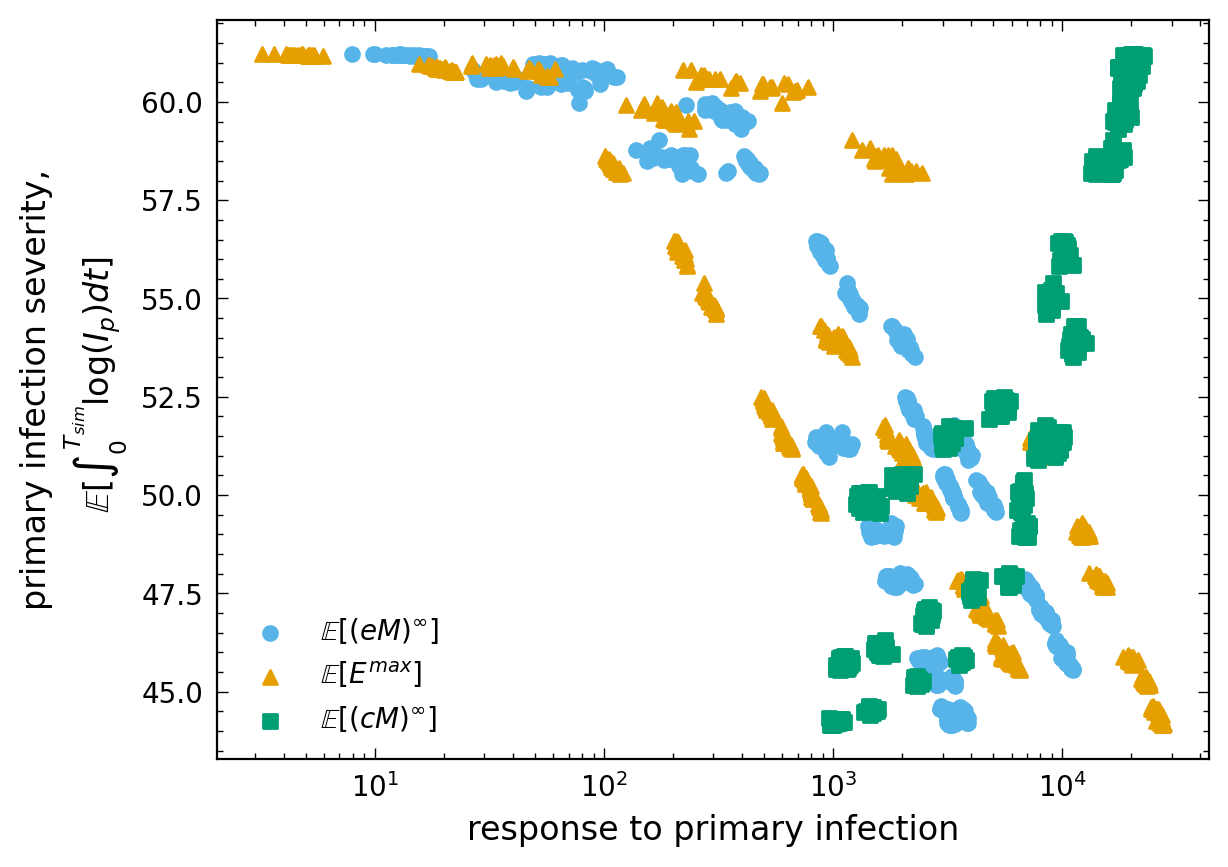

In [4]:
# plot memory and effector response against infection severity
p_harm = prim_net_data[:,-9]
int_eff = prim_net_data[:,-3]
max_eff = prim_net_data[:,-6]
inf_cm = prim_net_data[:,-4]
inf_em = prim_net_data[:,-1]
psi_EeM = prim_net_data[:,5] + prim_net_data[:,4]
low, high = 0, 1_000_000000

plt.scatter(inf_em, p_harm, marker = 'o', label = r"$\mathbb{E}[$"+stat_names[-1]+r"$]$")
plt.scatter(max_eff, p_harm, marker = '^', label = r"$\mathbb{E}[$"+stat_names[-6]+r"$]$")
plt.scatter(inf_cm, p_harm, marker = 's', label = r"$\mathbb{E}[$"+stat_names[-4]+r"$]$")

#plt.colorbar(label ="effector-effector memory regulation\n "+stat_names[4]+"+"+stat_names[5])

plt.xlabel('response to primary infection')
plt.ylabel("primary infection severity,\n $\mathbb{E}[$"+stat_names[-9]+r"$]$")
plt.legend()
plt.semilogx()
plt.savefig('_figs/p_harm_v_p_resp'+'.png', dpi=300, bbox_inches="tight")

(array([426.,  83.,  57.,   1.,  28.,  26.,   4.,  24.,  30.,  50.]),
 array([3.21093750e+00, 2.77188965e+03, 5.54056836e+03, 8.30924707e+03,
        1.10779258e+04, 1.38466045e+04, 1.66152832e+04, 1.93839619e+04,
        2.21526406e+04, 2.49213193e+04, 2.76899980e+04]),
 <BarContainer object of 10 artists>)

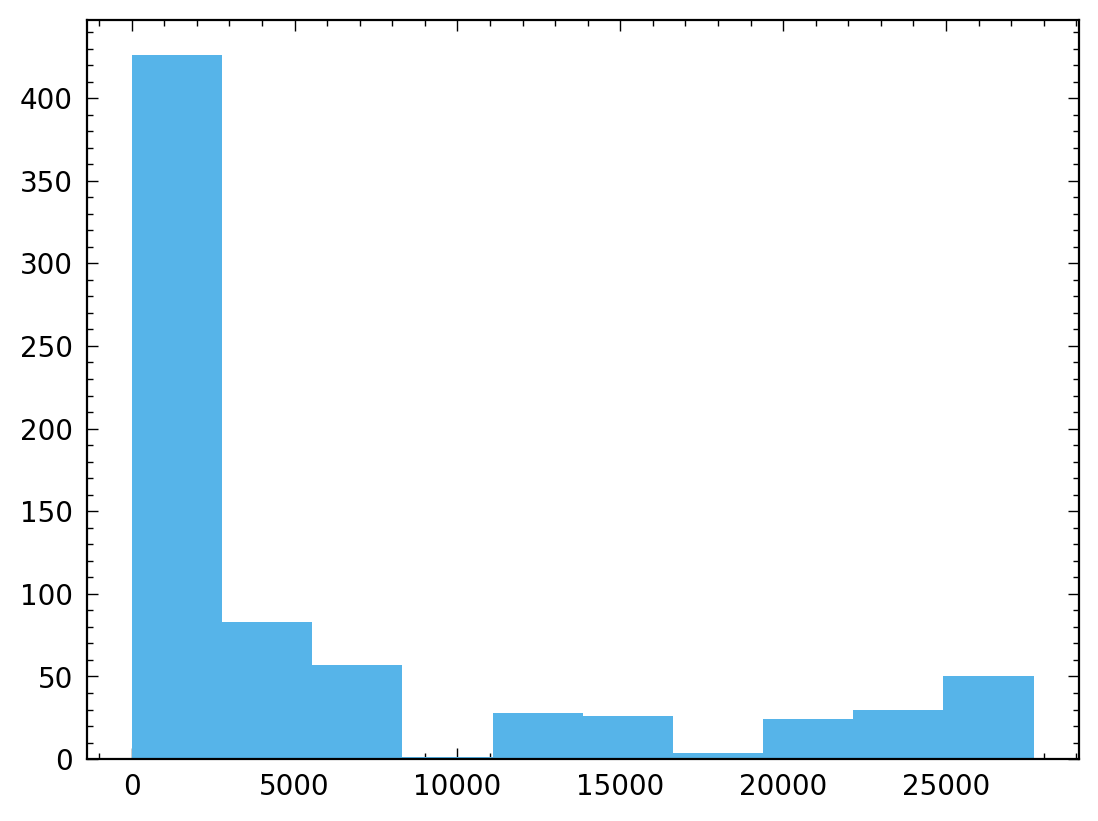

In [5]:
p_harm = prim_net_data[:,-9]
int_eff = prim_net_data[:,-3]
max_eff = prim_net_data[:,-6]
inf_cm = prim_net_data[:,-4]
inf_em = prim_net_data[:,-1]

plt.hist(max_eff)

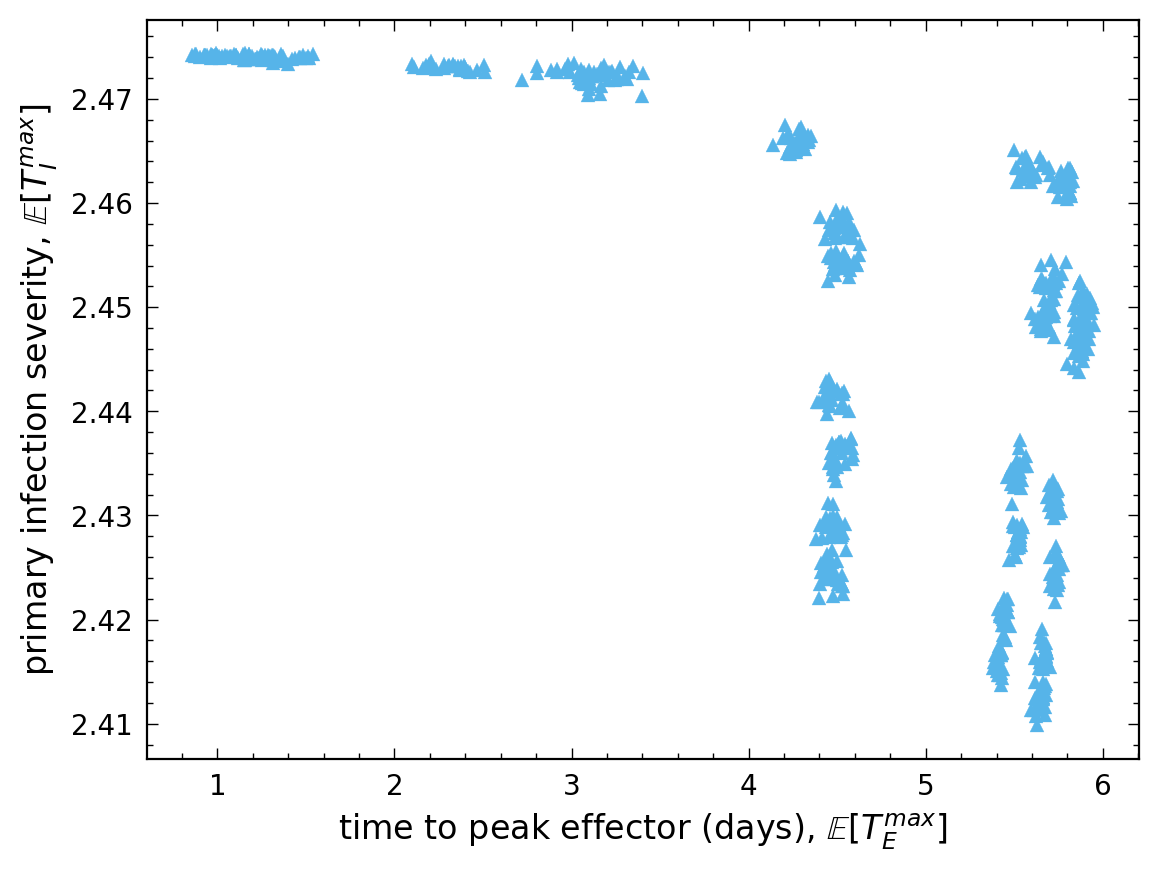

In [6]:
# plot time to peak effector response versus severity
t_harm = prim_net_data[:,-8]
t_eff = prim_net_data[:,-5]
thresh = 0

plt.plot(t_eff[t_eff >= thresh], t_harm[t_eff >= thresh],'^')
#plt.plot(max_eff[max_eff >= thresh], p_harm[max_eff >= thresh], 'r.', label = r"$\mathbb{E}[$"+stat_names[-6]+r"$]$")
plt.xlabel(r"time to peak effector (days), $\mathbb{E}[$"+stat_names[-5]+r"$]$")
plt.ylabel(r"primary infection severity, $\mathbb{E}[$"+stat_names[-8]+r"$]$")
#plt.semilogx()
plt.savefig('_figs/p_I_tmax_v_p_eff_tmax'+'.png', dpi=300, bbox_inches="tight")

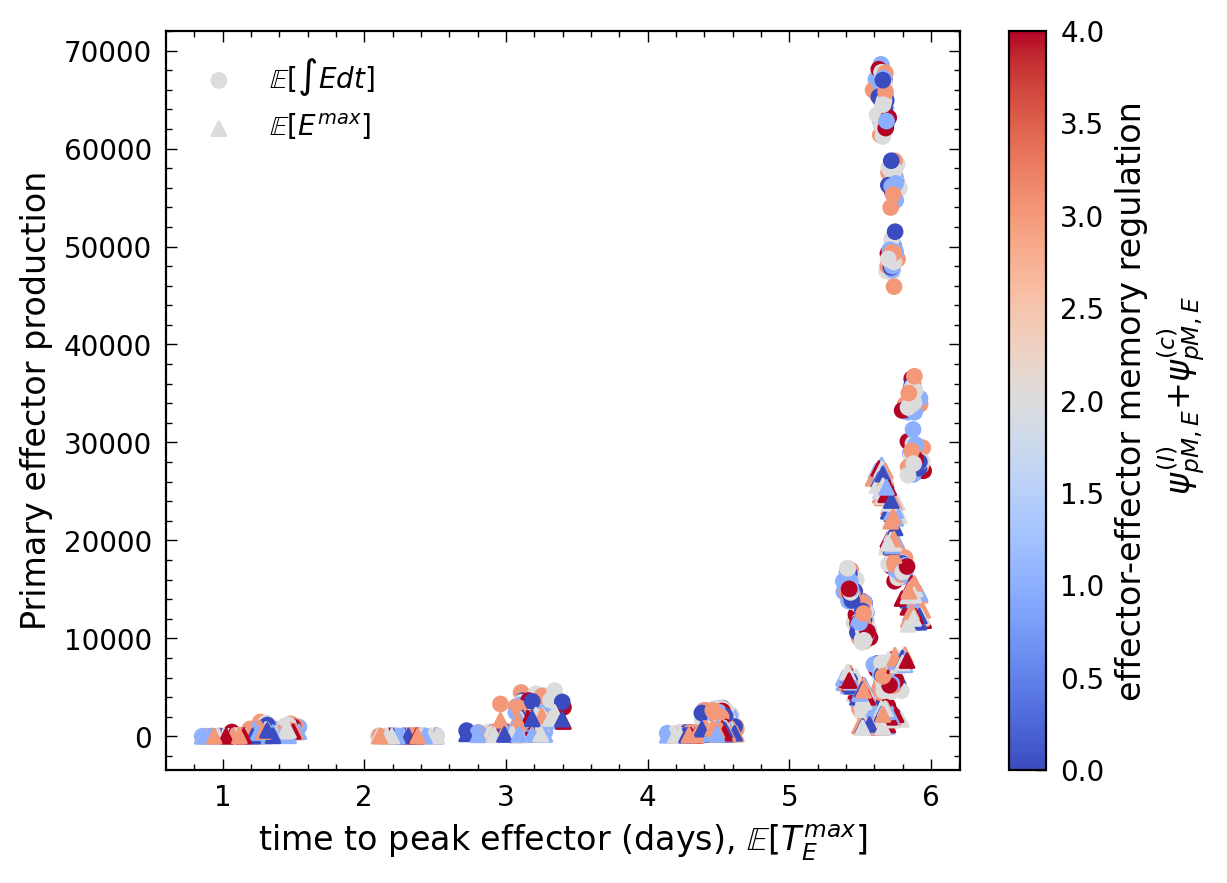

In [7]:
# plot time to peak effector response peak effector response
int_eff = prim_net_data[:,-3]
t_eff = prim_net_data[:,-5]
max_eff = prim_net_data[:,-6]
psi_EeM = prim_net_data[:,5] + prim_net_data[:,4]
thresh = 1

plt.scatter(t_eff[max_eff >= thresh], int_eff[max_eff >= thresh], c =psi_EeM[max_eff >= thresh], cmap='coolwarm',marker = 'o', label = r"$\mathbb{E}[$"+stat_names[-3]+r"$]$")
plt.scatter(t_eff[max_eff >= thresh], max_eff[max_eff >= thresh], c =psi_EeM[max_eff >= thresh], cmap='coolwarm',marker = '^', label = r"$\mathbb{E}[$"+stat_names[-6]+r"$]$")
plt.colorbar(label ="effector-effector memory regulation\n "+stat_names[4]+"+"+stat_names[5])

plt.xlabel(r"time to peak effector (days), $\mathbb{E}[$"+stat_names[-5]+r"$]$")
plt.ylabel(r"Primary effector production")
plt.legend()
#plt.semilogx()
plt.savefig('_figs/p_eff_tmax_v_p_eff_w_E_regs'+'.png', dpi=300, bbox_inches="tight")

There's a trade-off between producing effectors and central memory cells, which correlates with the severity sustained during an infection. However, effector memory production scales with effector production, as expected. The networks that do a pretty good job at both effector and memory production tend to minimize severity, but produce a lot more effector than memory.

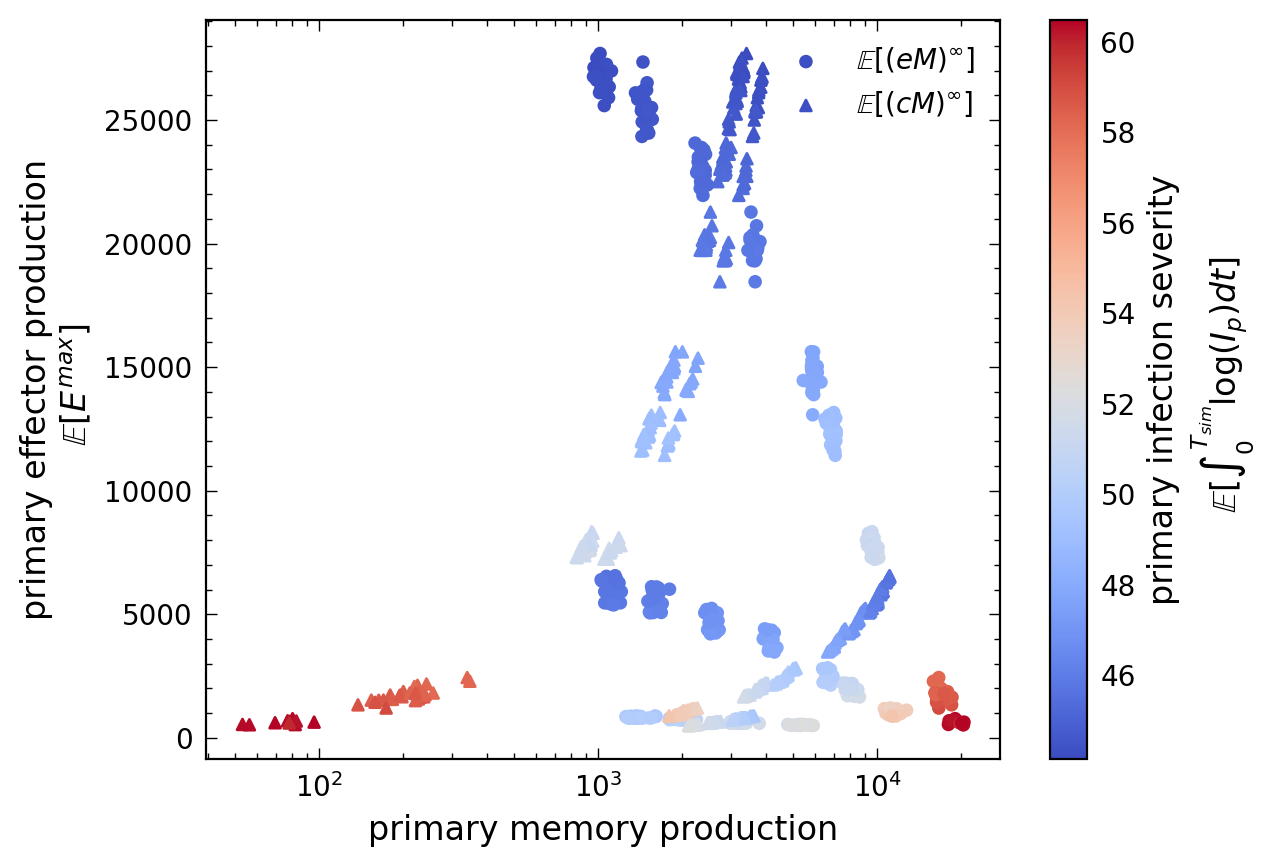

In [8]:
# plot time to memory response against effector response
inf_em = prim_net_data[:,-1]
max_eff = prim_net_data[:,-6]
inf_cm = prim_net_data[:,-4]
p_harm = prim_net_data[:,-9]
low, high = 500, 1_000_000

plt.scatter(inf_cm[(max_eff >= low)*(max_eff <= high)], max_eff[(max_eff >= low)*(max_eff <= high)], c = p_harm[(max_eff >= low)*(max_eff <= high)], cmap='coolwarm', s = 15, marker='o', label = r"$\mathbb{E}[$"+stat_names[-1]+r"$]$")
plt.scatter(inf_em[(max_eff >= low)*(max_eff <= high)], max_eff[(max_eff >= low)*(max_eff <= high)], c = p_harm[(max_eff >= low)*(max_eff <= high)], cmap='coolwarm', s = 15, marker='^', label = r"$\mathbb{E}[$"+stat_names[-4]+r"$]$")

plt.colorbar(label ="primary infection severity\n $\mathbb{E}[$"+stat_names[10]+r"$]$")

plt.xlabel(r"primary memory production")
plt.ylabel("primary effector production\n $\mathbb{E}[$"+stat_names[-6]+r"$]$")
plt.legend()
plt.semilogx()
#plt.semilogy()
plt.savefig('_figs/p_mem_v_p_eff'+'.png', dpi=300, bbox_inches="tight")

#### For feasible networks effector function correlates with Effectiveness and accuracy
Going forward we focus on the responsive networks and discard the sub-responsive and supra-responsive networks because the associated costs of severity and inflammation would presumably make them evolutionarily disadvantageous. When we focus on the networks that remain, we see that effector function correlates positively with effectiveness, and its correlation with accuracy depends on whether we look at antigenicity (negatively) or virulence (positively).

In [9]:
low, high = 1, 1_000_000
max_eff = prim_net_data[:,-6]
t_eff = prim_net_data[:,-5]
prim_net_kpt = prim_net_data[(max_eff >= low)*(max_eff <= high),:]
prim_net_kpt.shape

(729, 33)

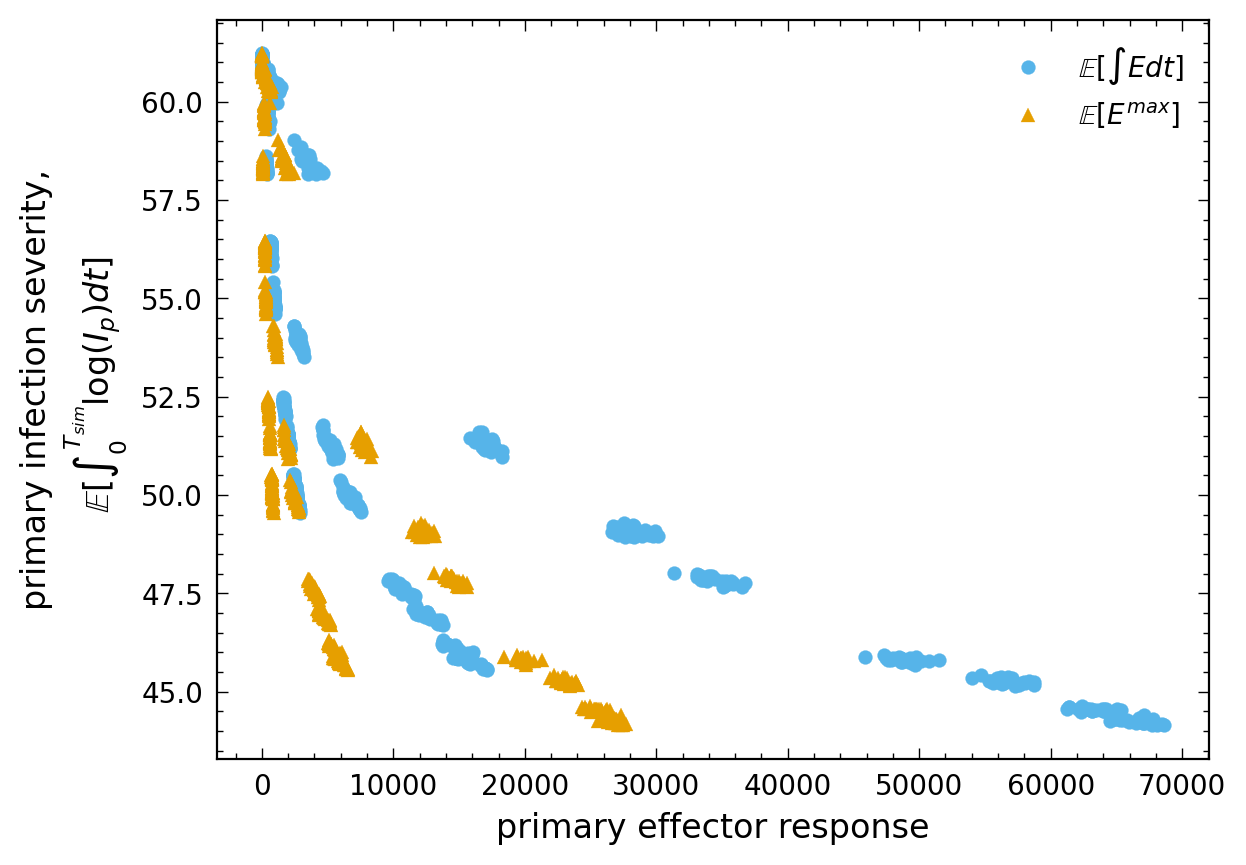

In [10]:
# plot effector response against primary infection severity for responsive networks
p_harm = prim_net_kpt[:,-9]
int_eff = prim_net_kpt[:,-3]
max_eff = prim_net_kpt[:,-6]

plt.plot(int_eff, p_harm, 'o', label = r"$\mathbb{E}[$"+stat_names[-3]+r"$]$")
plt.plot(max_eff, p_harm, '^', label = r"$\mathbb{E}[$"+stat_names[-6]+r"$]$")
#plt.plot(inf_mem[max_eff >= thresh], p_harm[max_eff >= thresh], 'b.', label = r"$\mathbb{E}[$"+stat_names[-4]+r"$]$")

plt.xlabel('primary effector response')
plt.ylabel("primary infection severity,\n $\mathbb{E}[$"+stat_names[-9]+r"$]$")
plt.legend()
#plt.semilogx()
plt.savefig('_figs/p_eff_v_p_harm'+'.png', dpi=300, bbox_inches="tight")

The positive association of effector function and virulence makes sense since the optimal response in the face of a faster growing pathogen is to produce more effectors to subdue the faster replicating pathogen. The negative association between effector function and antigenicity could relate to limits on the ability of cells to resolve antigenicity.

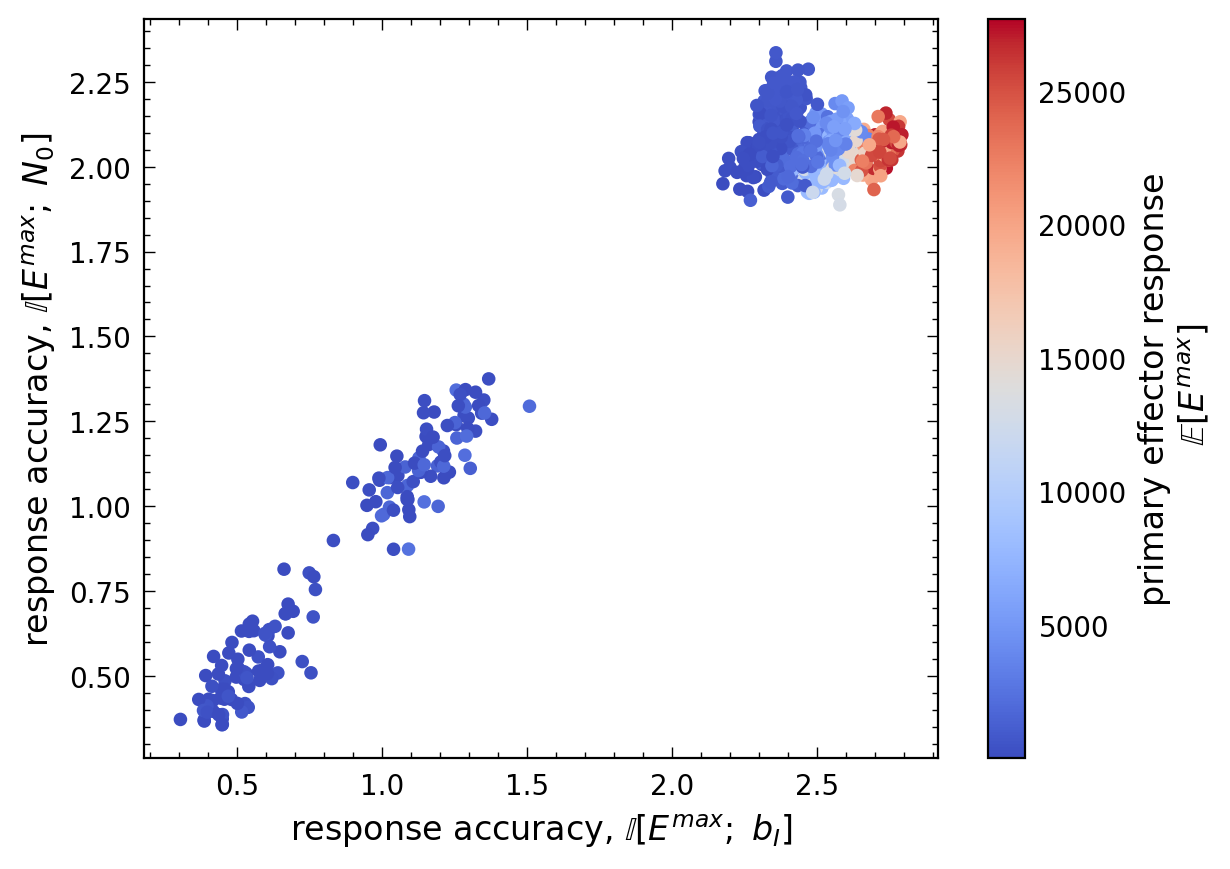

In [11]:
# plot accuracy of effector response wrt virulence and antigenicity
mi_eff_N_0 = prim_net_kpt[:,9]
mi_eff_d_I = prim_net_kpt[:,18]
int_eff = prim_net_kpt[:,-3]
max_eff = prim_net_kpt[:,-6]
t_eff = prim_net_kpt[:,-5]

#plt.scatter(x[z < thresh], y[z < thresh], c=z[z < thresh], cmap='coolwarm', s = 5)

plt.scatter(mi_eff_d_I, mi_eff_N_0, c = max_eff, cmap='coolwarm', s = 15) #, label = "antigenicity, "+stat_names[8],marker ='.')
#plt.scatter(int_eff[(int_eff >= low)*(int_eff <= high)], mi_eff_d_I[(int_eff >= low)*(int_eff <= high)], c = z, cmap='coolwarm', s = 15, label = "virulence, "+stat_names[7],marker ='^')
plt.colorbar(label ="primary effector response\n $\mathbb{E}[$"+stat_names[13]+r"$]$")

plt.xlabel(r"response accuracy, $\mathbb{I}[$"+stat_names[13]+r"$;~$"+stat_names[7]+"$]$")
plt.ylabel(r"response accuracy, $\mathbb{I}[$"+stat_names[13]+r"$;~$"+stat_names[8]+"$]$")

#plt.legend()
#plt.semilogx()
plt.savefig('_figs/p_sens_bI_v_p_sens_N_0_w_peff'+'.png', dpi=300, bbox_inches="tight")

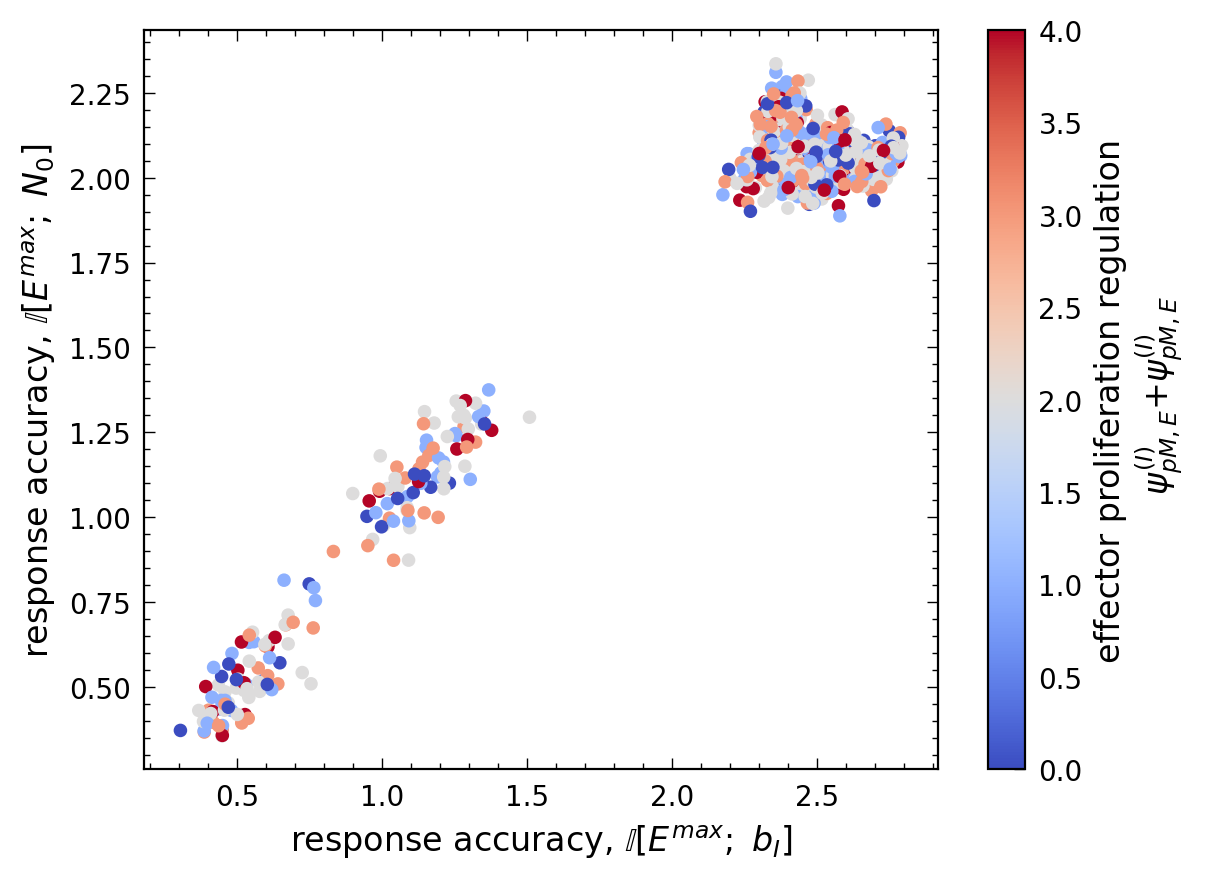

In [12]:
# plot accuracy of effector response wrt virulence and antigenicity
mi_eff_N_0 = prim_net_kpt[:,9]
mi_eff_d_I = prim_net_kpt[:,18]
int_eff = prim_net_kpt[:,-3]
max_eff = prim_net_kpt[:,-6]
reg_eff = prim_net_kpt[:,4]+prim_net_kpt[:,5]

#plt.scatter(x[z < thresh], y[z < thresh], c=z[z < thresh], cmap='coolwarm', s = 5)

plt.scatter(mi_eff_d_I, mi_eff_N_0, c = reg_eff, cmap='coolwarm', s = 15) #, label = "antigenicity, "+stat_names[8],marker ='.')
#plt.scatter(int_eff[(int_eff >= low)*(int_eff <= high)], mi_eff_d_I[(int_eff >= low)*(int_eff <= high)], c = z, cmap='coolwarm', s = 15, label = "virulence, "+stat_names[7],marker ='^')
plt.colorbar(label ="effector proliferation regulation\n "+stat_names[4]+"+"+stat_names[4])

plt.xlabel(r"response accuracy, $\mathbb{I}[$"+stat_names[13]+r"$;~$"+stat_names[7]+"$]$")
plt.ylabel(r"response accuracy, $\mathbb{I}[$"+stat_names[13]+r"$;~$"+stat_names[8]+"$]$")

#plt.legend()
#plt.semilogx()
plt.savefig('_figs/p_sens_bI_v_p_sens_N_0_w_reg_E'+'.png', dpi=300, bbox_inches="tight")

#### A closer look at effective and reliable network architechtures
The most effective networks prioritize effector production over memory production, early on during the infection. This is highlighted by the need to upregulated effector differentiation from naive cells ($\psi_{N,E}^{(I)}$). To sustain the response, the system needs to commit to effector production until it can be sure the infection is cleared ($\psi_{E,E}^{(I,c)}$). Interestingly, we note that the networks that produce the most effector are not the best at reducing severity. These networks generally under-produce effectors at the beginning of an infection and over-compensate in the later stages of an infection.

To what extent do these results depend on the potency of effectors to clear infections and the relative advantage of memory cells over naive cells?

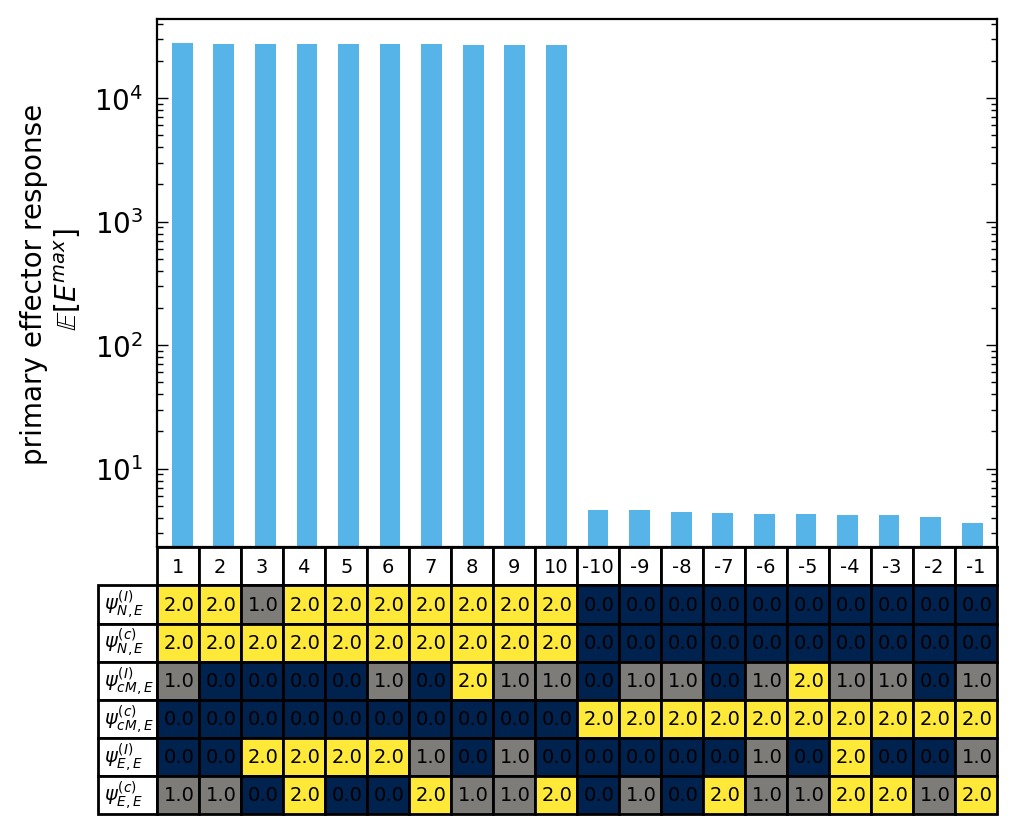

In [13]:
# plot ranking of networks based on effector response
n = -6
eff_rank_net = prim_net_kpt[(-prim_net_kpt[:, n]).argsort()]

fig, ax = plt.subplots(figsize=(6,3))
r = np.arange(20)
width = 0.5

opt_regs = np.round_(np.vstack((eff_rank_net[:10,0:6], eff_rank_net[-11:-1,0:6])),2).T
norm = plt.Normalize(opt_regs.min(), opt_regs.max())
colours = plt.cm.cividis(norm(opt_regs))

ax.bar(r, np.append(eff_rank_net[0:10, n], 
                     eff_rank_net[-11:-1, n],  axis = 0), width = width, label = r'vary $N_0$',
       align='center')
# align bars with table
ax.set_xlim(-0.6, 19.6)

the_table = ax.table(cellText= opt_regs,
                      rowLabels=[r"$\psi_{N,E}^{(I)}$", r"$\psi_{N,E}^{(c)}$", r"$\psi_{cM,E}^{(I)}$", r"$\psi_{cM,E}^{(c)}$", r"$\psi_{E,E}^{(I)}$", r"$\psi_{E,E}^{(c)}$"],
                      colLabels=[1,2,3,4,5,6,7,8,9,10,-10,-9,-8,-7,-6, -5, -4, -3,-2,-1],
                      loc='bottom',
                      cellColours = colours)

plt.subplots_adjust(left=0.2, bottom=0.0)
#plt.ylabel(r"$\mathbb{E}[$"+stat_names[10]+r"$]$", fontsize = 16)
ax.set_ylabel("primary effector response\n $\mathbb{E}[$"+stat_names[13]+r"$]$", fontsize = 10)
#plt.xlabel('rank', fontsize = 16)
ax.set_xticks([])
ax.set_xticklabels([])
plt.semilogy()

plt.savefig('_figs/rank_p_eff'+'.png', dpi=300, bbox_inches="tight")

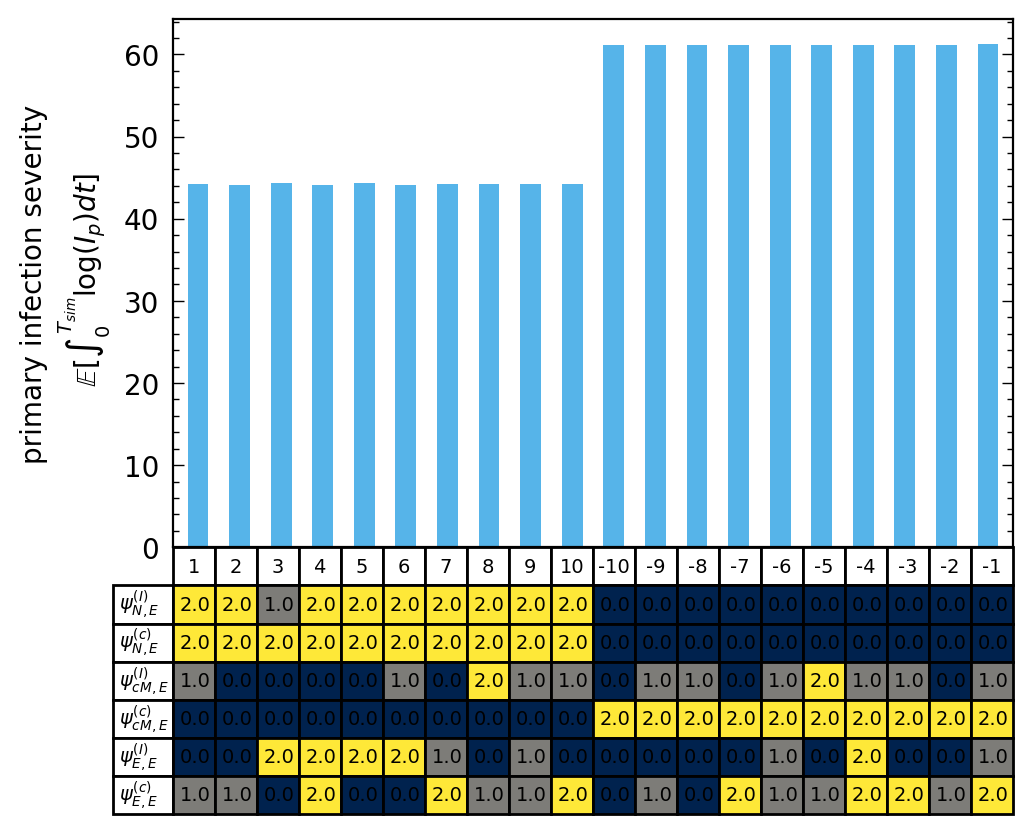

In [14]:
# plot ranking of networks based on severity
n = -7
eff_rank_net = prim_net_kpt[(-prim_net_kpt[:, -6]).argsort()]

fig, ax = plt.subplots(figsize=(6,3))
r = np.arange(20)
width = 0.5

opt_regs = np.round_(np.vstack((eff_rank_net[:10,0:6], eff_rank_net[-11:-1,0:6])),2).T
norm = plt.Normalize(opt_regs.min(), opt_regs.max())
colours = plt.cm.cividis(norm(opt_regs))

ax.bar(r,
       np.append(eff_rank_net[0:10, n], eff_rank_net[-11:-1, n],  axis = 0),
       width = width, label = r'vary $N_0$',
       align='center')
# align bars with table
ax.set_xlim(-0.6, 19.6)

the_table = ax.table(cellText= opt_regs,
                      rowLabels=[r"$\psi_{N,E}^{(I)}$", r"$\psi_{N,E}^{(c)}$", r"$\psi_{cM,E}^{(I)}$", r"$\psi_{cM,E}^{(c)}$", r"$\psi_{E,E}^{(I)}$", r"$\psi_{E,E}^{(c)}$"],
                      colLabels=[1,2,3,4,5,6,7,8,9,10,-10,-9,-8,-7,-6, -5, -4, -3,-2,-1],
                      loc='bottom',
                      cellColours = colours)

plt.subplots_adjust(left=0.2, bottom=0.0)
#plt.ylabel(r"$\mathbb{E}[$"+stat_names[10]+r"$]$", fontsize = 16)
ax.set_ylabel("primary infection severity\n $\mathbb{E}[$"+stat_names[-9]+r"$]$", fontsize = 10)
#plt.xlabel('rank', fontsize = 16)
ax.set_xticks([])
ax.set_xticklabels([])

plt.savefig('_figs/rank_p_harm_by_p_eff'+'.png', dpi=300, bbox_inches="tight")

First, we note that comparable levels of mutual information between effector response, and antigenicity and virulence are achievable (albeit by different networks). Maximizing mutual information w.r.t. antigenicity requires down-regulating effector response, while mutual information w.r.t. virulence can be maximized without regulating or up-regulating effector response.

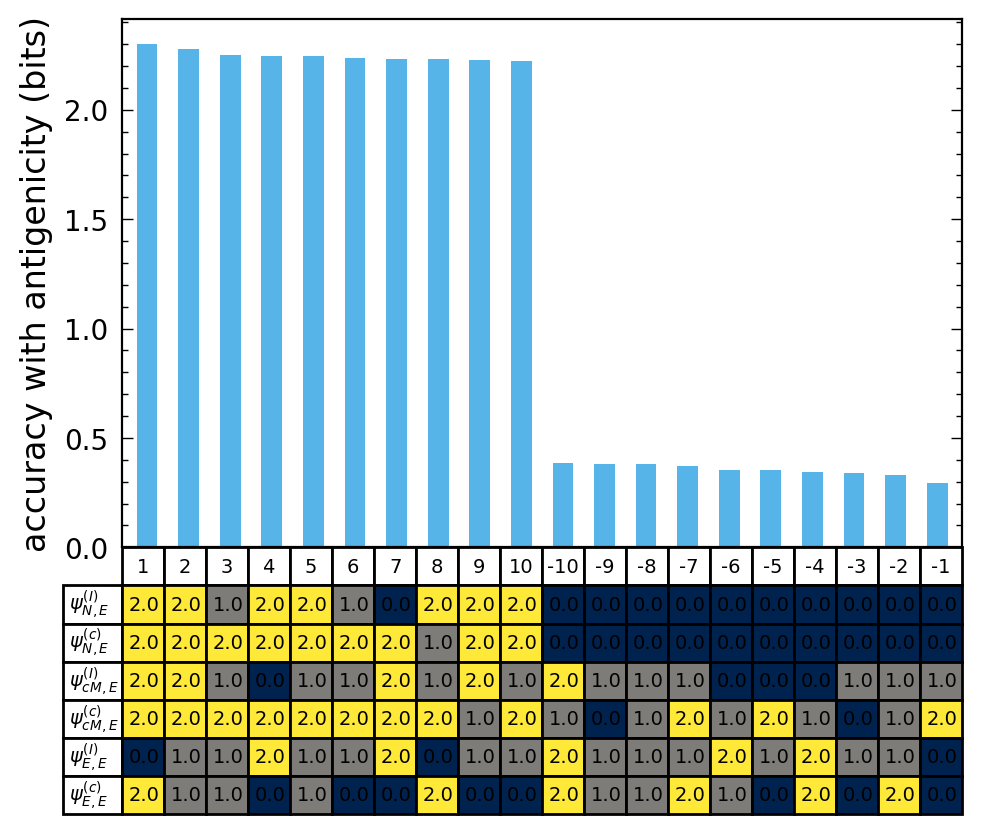

In [15]:
# plot ranking of networks based on mutual information between effector response: antigenicity
n = 12
eff_rank_net = prim_net_kpt[(-prim_net_kpt[:, n]).argsort()]

fig, ax = plt.subplots(figsize=(6,3)) 
r = np.arange(20)
width = 0.5
opt_regs = np.round_(np.vstack((eff_rank_net[:10,0:6], eff_rank_net[-11:-1,0:6])),2).T
norm = plt.Normalize(opt_regs.min(), opt_regs.max())
colours = plt.cm.cividis(norm(opt_regs))

ax.bar(r, np.append(eff_rank_net[0:10, n], eff_rank_net[-11:-1, n], axis = 0), width = width, label = r'vary $N_0$',
       align='center')
# align bars with table
ax.set_xlim(-0.6, 19.6)

the_table = ax.table(cellText= opt_regs,
                      rowLabels=[r"$\psi_{N,E}^{(I)}$", r"$\psi_{N,E}^{(c)}$", r"$\psi_{cM,E}^{(I)}$", r"$\psi_{cM,E}^{(c)}$", r"$\psi_{E,E}^{(I)}$", r"$\psi_{E,E}^{(c)}$"],
                      colLabels=[1,2,3,4,5,6,7,8,9,10,-10,-9,-8,-7,-6, -5, -4, -3,-2,-1],
                      loc='bottom',
                      cellColours = colours)

plt.subplots_adjust(left=0.2, bottom=0.0)
#plt.ylabel( r"$I($"+stat_names[16]+r";$N_0)$", fontsize = 16)
ax.set_ylabel("accuracy with antigenicity (bits)", fontsize = 12)
#plt.xlabel('rank', fontsize = 16)
ax.set_xticks([])


plt.savefig('_figs/rank_p_sens_N_0'+'.png', dpi=300, bbox_inches="tight")

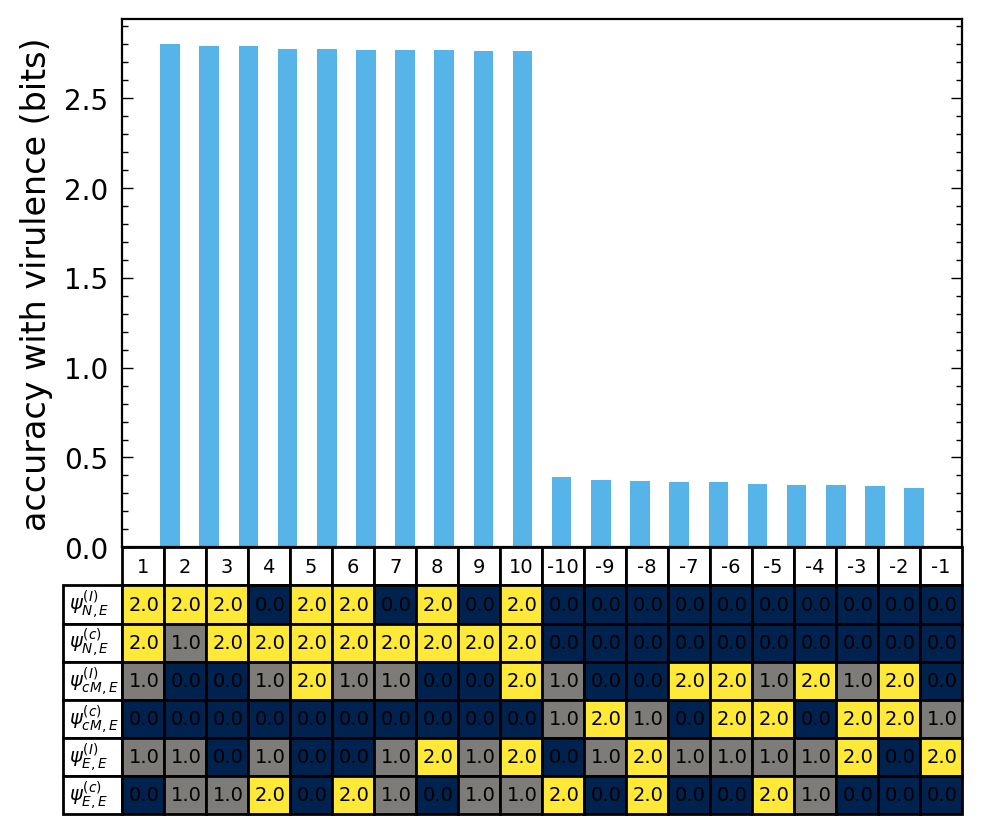

In [16]:
# plot ranking of networks based on mutual information between effector response: virulence
n = 21
eff_rank_net = prim_net_kpt[(-prim_net_kpt[:, n]).argsort()]

plt.figure(figsize=(6,3))  
r = np.arange(20)
width = 0.5
opt_regs = np.round_(np.vstack((eff_rank_net[:10,0:6], eff_rank_net[-11:-1,0:6])),2).T
norm = plt.Normalize(opt_regs.min(), opt_regs.max())
colours = plt.cm.cividis(norm(opt_regs))

plt.bar(r, np.append(eff_rank_net[0:10, n], eff_rank_net[-11:-1, n], axis = 0), width = width, label = r'vary $N_0$')

the_table = plt.table(cellText= opt_regs,
                      rowLabels=[r"$\psi_{N,E}^{(I)}$", r"$\psi_{N,E}^{(c)}$", r"$\psi_{cM,E}^{(I)}$", r"$\psi_{cM,E}^{(c)}$", r"$\psi_{E,E}^{(I)}$", r"$\psi_{E,E}^{(c)}$"],
                      colLabels=[1,2,3,4,5,6,7,8,9,10,-10,-9,-8,-7,-6, -5, -4, -3,-2,-1],
                      loc='bottom',
                      cellColours = colours)

plt.subplots_adjust(left=0.2, bottom=0.0)
#plt.ylabel( r"$I($"+stat_names[16]+r";$N_0)$", fontsize = 16)
plt.ylabel("accuracy with virulence (bits)", fontsize = 12)
#plt.xlabel('rank', fontsize = 16)
plt.xticks([])


plt.savefig('_figs/rank_p_sens_bI'+'.png', dpi=300, bbox_inches="tight")

## Secondary infections

In [17]:
# Load data from secondary infections
sim_kind = 'agent'
infection_type = 'sec'
d = '/mmfs1/home/oukogu/github/infoimmune/opt_nets/'

nets = []

for f in tqdm(os.listdir(d)):
    if '500-' not in f or infection_type not in f:
        continue
    filepath = os.path.join(d, f)
    nets.append(np.load(filepath))
    
sec_net_data = np.vstack(nets)
print(sec_net_data.shape)

100%|██████████████████████████████████████████████████████████████████████████████████| 1463/1463 [00:00<00:00, 11635.27it/s]

(729, 33)


In [18]:
# combine data from primary and secondary infection simulations
prim_df = pd.DataFrame(prim_net_data, columns = ['p_'+ i for i in stat_names_for_df])
sec_df = pd.DataFrame(sec_net_data, columns = ['s_'+ i for i in stat_names_for_df])

full_net_data = sec_df.merge(prim_df, how='left', 
                                         left_on=['s_psi_NE_c','s_psi_NE_I','s_psi_EeM_c','s_psi_EeM_I','s_psi_pME_c','s_psi_pME_I'], 
                                         right_on=['p_psi_NE_c','p_psi_NE_I','p_psi_EeM_c','p_psi_EeM_I','p_psi_pME_c','p_psi_pME_I'])

print(full_net_data.columns)

Index(['s_psi_NE_c', 's_psi_NE_I', 's_psi_EeM_c', 's_psi_EeM_I', 's_psi_pME_c',
       's_psi_pME_I', 's_mi_N_0_p_harm', 's_mi_N_0_T_max_I', 's_mi_N_0_s_harm',
       's_mi_N_0_max_E', 's_mi_N_0_T_max_E', 's_mi_N_0_inf_cM',
       's_mi_N_0_int_E', 's_mi_N_0_int_logE', 's_mi_N_0_inf_eM',
       's_mi_d_I_p_harm', 's_mi_d_I_T_max_I', 's_mi_d_I_s_harm',
       's_mi_d_I_max_E', 's_mi_d_I_T_max_E', 's_mi_d_I_inf_cM',
       's_mi_d_I_int_E', 's_mi_d_I_int_logE', 's_mi_d_I_int_eM', 's_p_harm',
       's_T_max_I', 's_s_harm', 's_max_E', 's_T_max_E', 's_inf_cM', 's_int_E',
       's_int_logE', 's_inf_eM', 'p_psi_NE_c', 'p_psi_NE_I', 'p_psi_EeM_c',
       'p_psi_EeM_I', 'p_psi_pME_c', 'p_psi_pME_I', 'p_mi_N_0_p_harm',
       'p_mi_N_0_T_max_I', 'p_mi_N_0_s_harm', 'p_mi_N_0_max_E',
       'p_mi_N_0_T_max_E', 'p_mi_N_0_inf_cM', 'p_mi_N_0_int_E',
       'p_mi_N_0_int_logE', 'p_mi_N_0_inf_eM', 'p_mi_d_I_p_harm',
       'p_mi_d_I_T_max_I', 'p_mi_d_I_s_harm', 'p_mi_d_I_max_E',
       'p_mi_d_I_T_ma

The best responses don't peak too early or too late. Secondary infection severity decreases with the effector response and generally increases with the central memory.

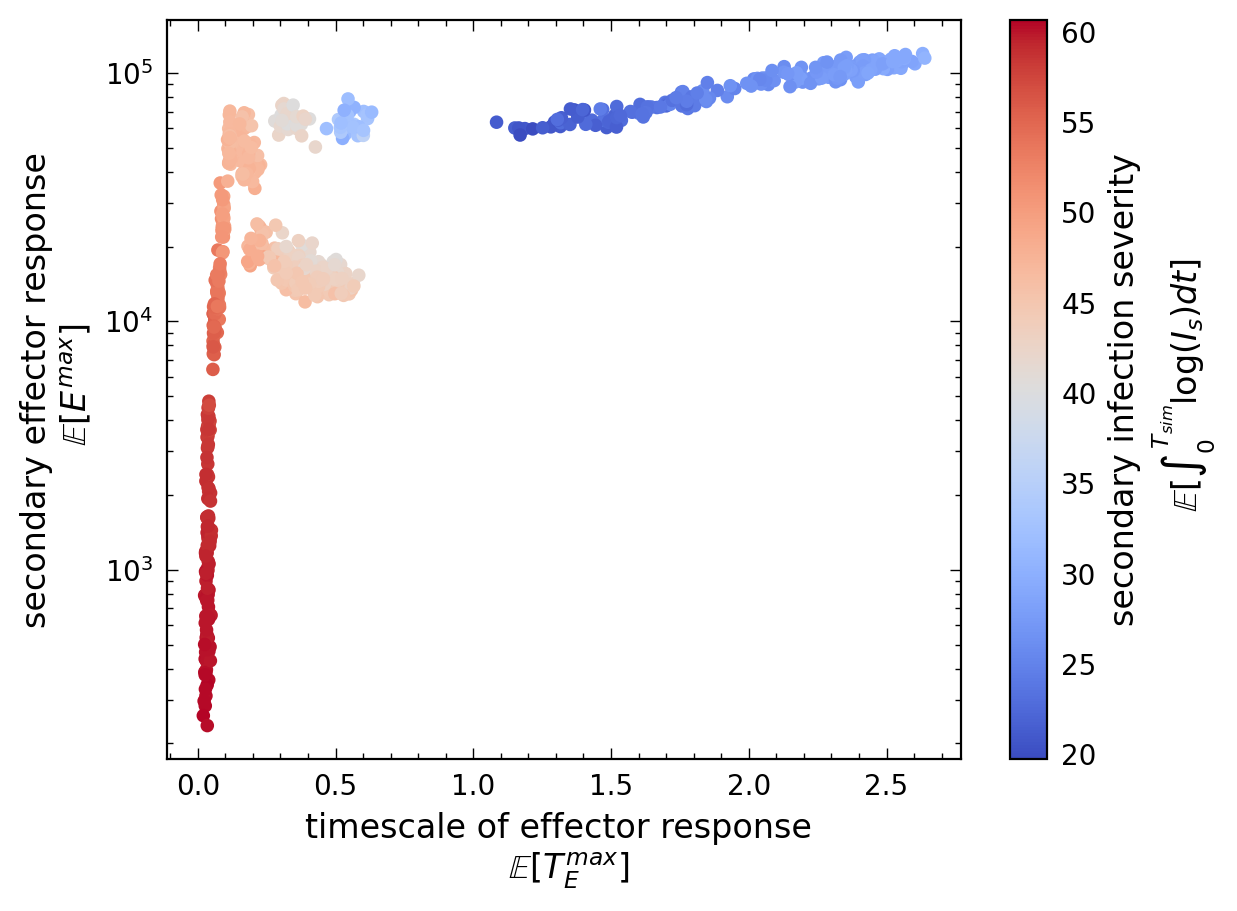

In [19]:
p_harm = full_net_data['s_p_harm']
s_harm = full_net_data['s_s_harm']
s_max_eff = full_net_data['s_max_E']
s_t_eff = full_net_data['s_T_max_E']
s_t_I = full_net_data['s_T_max_I']
low, high = 1000, 200
mean_thresh = 25000

plt.scatter(s_t_eff, s_max_eff, c = s_harm, cmap='coolwarm', s = 15, marker ='o')
plt.colorbar(label ="secondary infection severity\n $\mathbb{E}[$"+stat_names[-7]+r"$]$")
plt.ylabel("secondary effector response\n $\mathbb{E}[$"+stat_names[13]+r"$]$")
plt.xlabel("timescale of effector response \n $\mathbb{E}[$"+stat_names[14]+r"$]$")

#plt.xlabel("timescale of effector response \n $\mathbb{E}[$"+stat_names[14]+r"$]/ \mathbb{E}[$"+stat_names[11]+r"$]$")
plt.semilogy()

plt.savefig('_figs/t_max_eff_v_s_harm'+'.png', dpi=300, bbox_inches="tight")

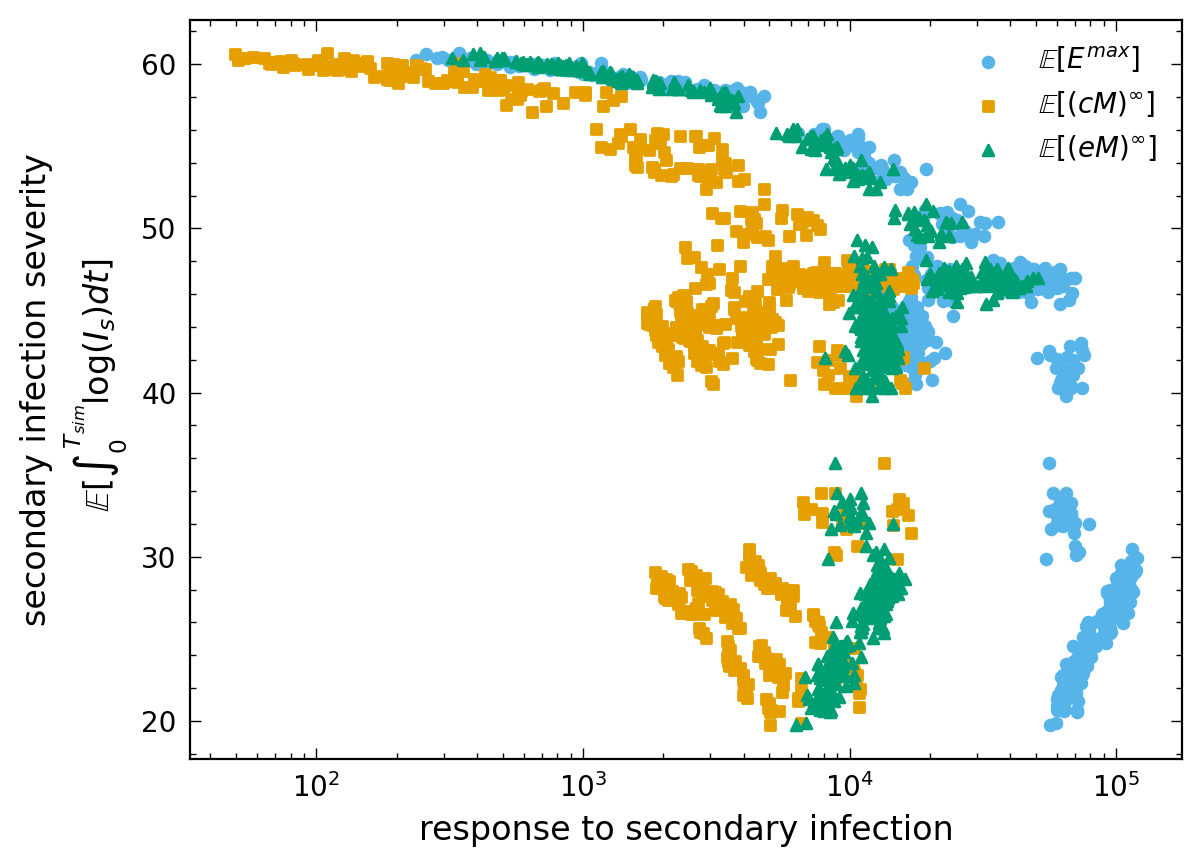

In [20]:
s_harm = full_net_data['s_s_harm']
s_max_eff = full_net_data['s_max_E']
s_inf_cm = full_net_data['s_inf_cM']
s_inf_em = full_net_data['s_inf_eM']
low, high = 1000, 200
mean_thresh = 25000

plt.scatter(s_max_eff, s_harm, s = 15, marker ='o', label = r"$\mathbb{E}[$"+stat_names[-6]+r"$]$")
plt.scatter(s_inf_cm, s_harm, s = 15, marker ='s', label = r"$\mathbb{E}[$"+stat_names[-4]+r"$]$")
plt.scatter(s_inf_em, s_harm, s = 15, marker ='^', label = r"$\mathbb{E}[$"+stat_names[-1]+r"$]$")
plt.legend()
plt.xlabel("response to secondary infection")
plt.ylabel("secondary infection severity\n $\mathbb{E}[$"+stat_names[-7]+r"$]$")
plt.semilogx()

plt.savefig('_figs/s_resp_v_s_harm'+'.png', dpi=300, bbox_inches="tight")

### Network architechtures that optimize evolutionary anticipation
Plotting the severity from a primary infection against the severity from a secondary infection for all networks, we observe a complicated relationship. The least effective networks (highest severity from primary infection) have the lowest primary effector function, and also have the highest secondary infection severity. Curiously, the most effective networks (lowest severity from primary infection) have the highest primary effector function, and also have the very high secondary infection severity. 

There is a goldilocks effect in primary effector response, where the best outcomes are realized. These are the networks that produce just enough effector and just enough memory. We see that the networks with higher memory generally see the highest fold change decrease in severity (more anticipation).

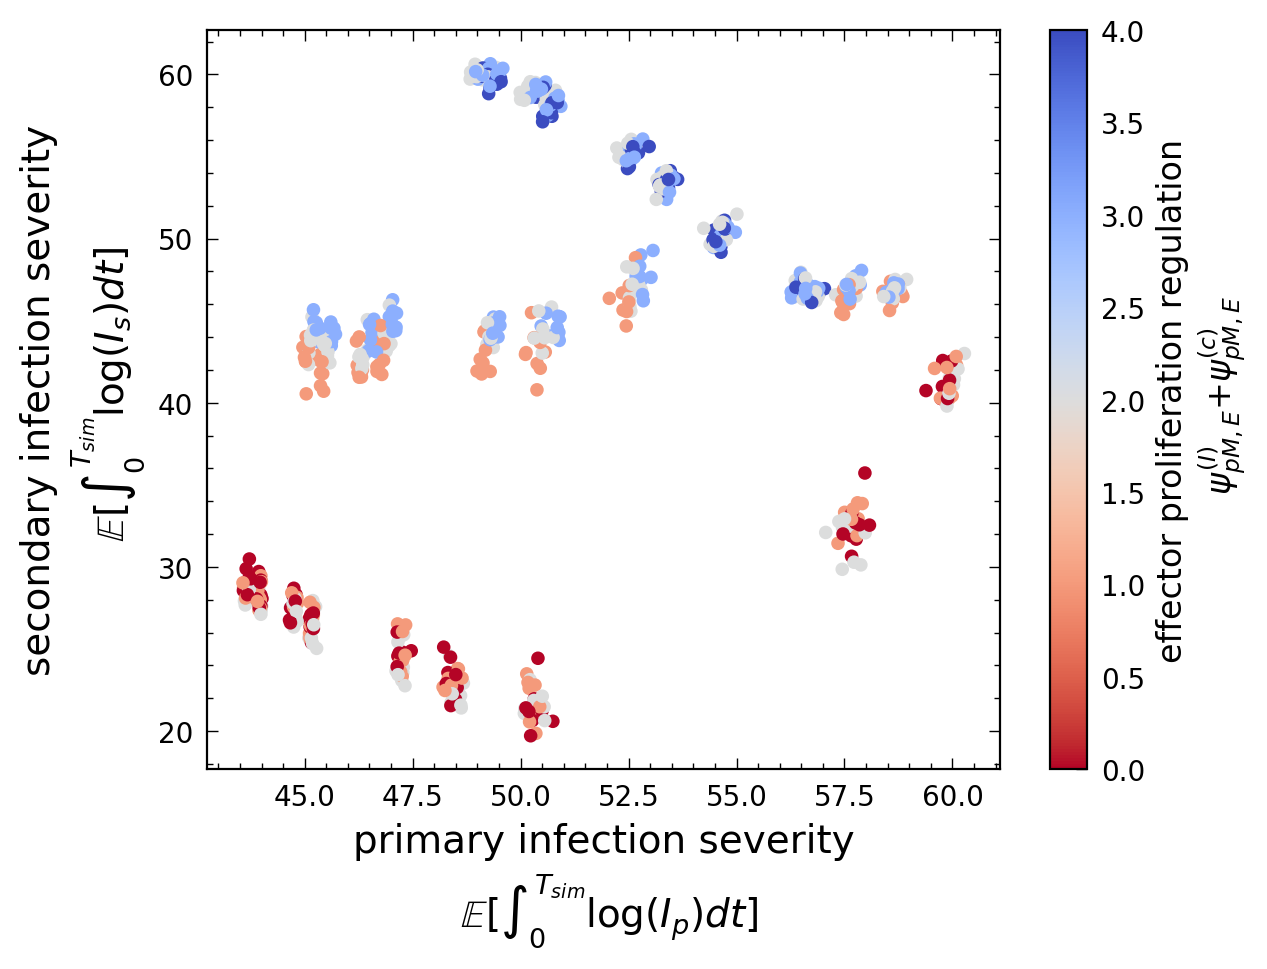

In [21]:
p_harm = full_net_data['s_p_harm']
s_harm = full_net_data['s_s_harm']
z = 0*full_net_data['s_psi_NE_c'] + full_net_data['s_psi_EeM_c'] + full_net_data['s_psi_EeM_I']
low, high = 1000, 50_000
mean_thresh = 25000

plt.scatter(p_harm, s_harm, c = z, cmap = plt.cm.coolwarm_r, s = 15, marker ='o')
plt.colorbar(label ="effector proliferation regulation\n "+stat_names[4]+"+"+stat_names[5])

#plt.scatter(p_harm[(p_max_eff >= high)], s_harm[(p_max_eff >= high)], c = p_max_eff[(p_max_eff >= high)], cmap='coolwarm', s = 15,marker ='^')
plt.ylabel("secondary infection severity\n $\mathbb{E}[$"+stat_names[-7]+r"$]$", fontsize = 14)
plt.xlabel("primary infection severity\n $\mathbb{E}[$"+stat_names[-9]+r"$]$", fontsize = 14)

plt.savefig('_figs/p_harm_v_s_harm_w_p_eff_regs'+'.png', dpi=300, bbox_inches="tight")

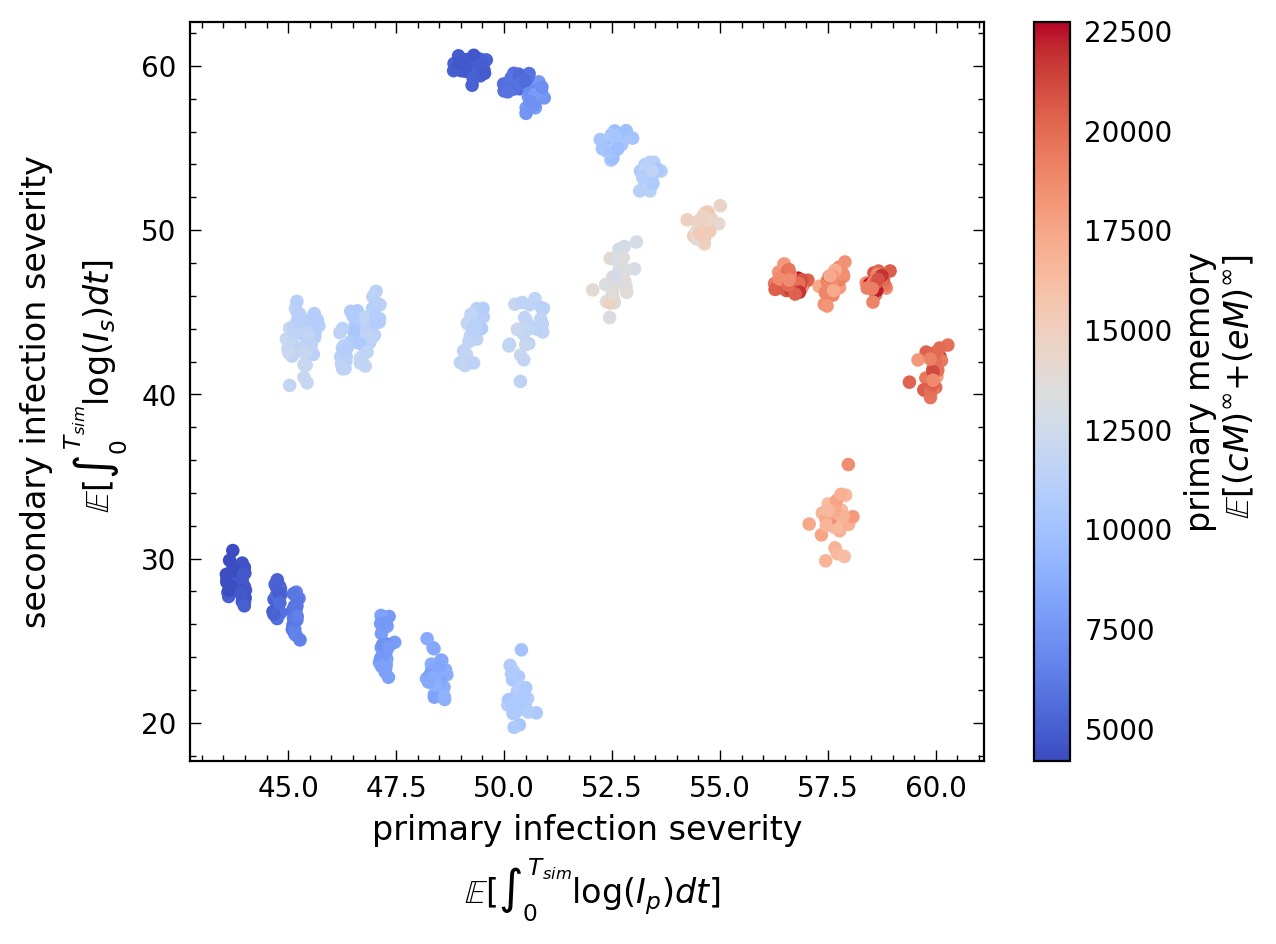

In [22]:
p_harm = full_net_data['s_p_harm']
s_harm = full_net_data['s_s_harm']
p_inf_mem = full_net_data['p_inf_cM'] + full_net_data['p_inf_eM']

s_t_eff = full_net_data['s_T_max_E']
low, high = 2, 10
mean_thresh = 2

plt.scatter(p_harm, s_harm, c = p_inf_mem, cmap='coolwarm', s = 15, marker ='o')

plt.colorbar(label ="primary memory\n $\mathbb{E}[$"+stat_names[-4]+"+"+stat_names[-1]+r"$]$")
#plt.scatter(p_harm[(s_t_eff <= low)], s_harm[(s_t_eff <= low)], c = s_t_eff[(s_t_eff <= low)], cmap='coolwarm', s = 15,marker ='^')
plt.ylabel("secondary infection severity\n $\mathbb{E}[$"+stat_names[-7]+r"$]$")
plt.xlabel("primary infection severity\n $\mathbb{E}[$"+stat_names[-9]+r"$]$")

plt.savefig('_figs/p_harm_v_s_harm_w_p_mem'+'.png', dpi=300, bbox_inches="tight")

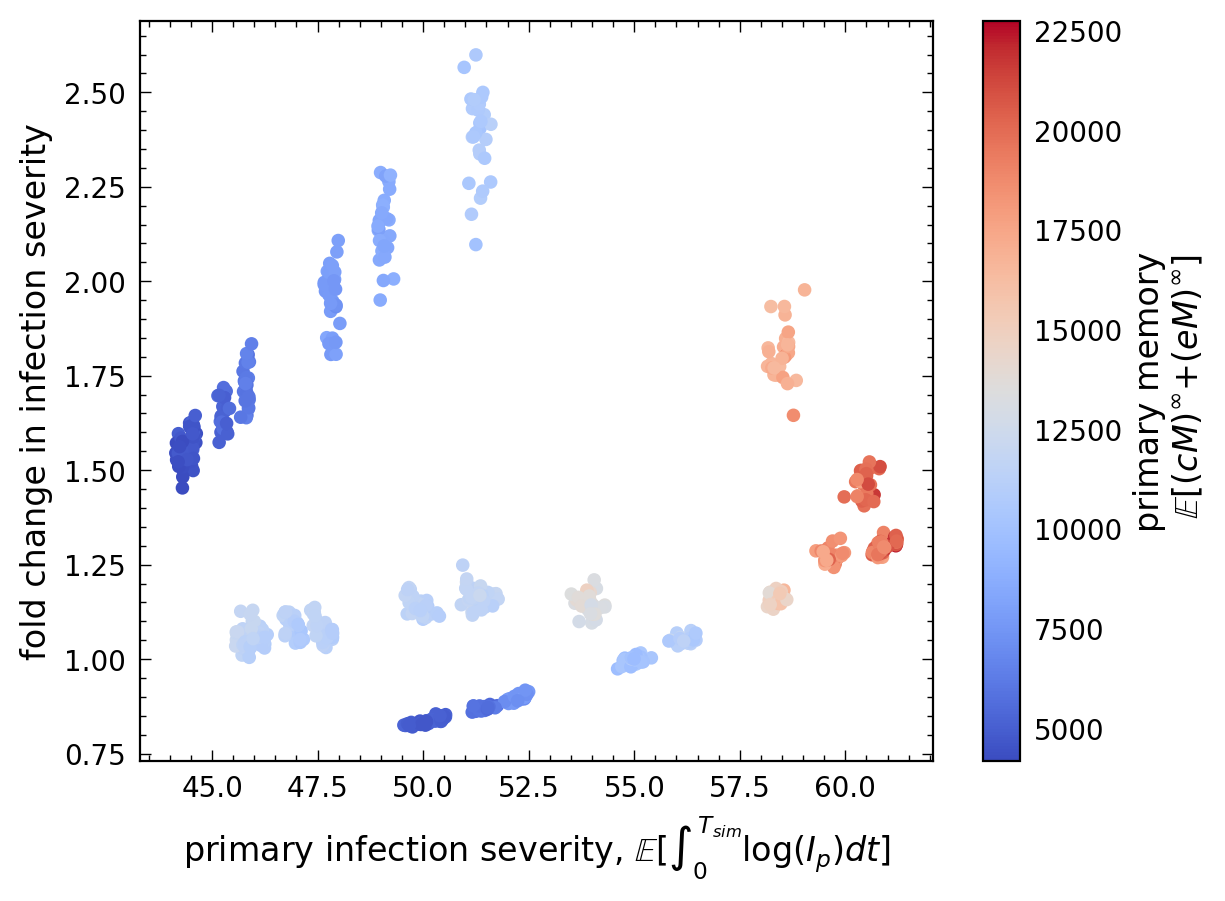

In [23]:
p_harm = full_net_data['p_p_harm']
s_harm = full_net_data['s_s_harm']
p_int_eff = full_net_data['p_int_E']
p_inf_mem = full_net_data['p_inf_cM'] + full_net_data['p_inf_eM']
fld_chg = p_harm/s_harm

low, high = 1000, 1_000_000

plt.scatter(p_harm, fld_chg, 
            c = p_inf_mem, cmap='coolwarm', s = 15)
plt.colorbar(label ="primary memory\n $\mathbb{E}[$"+stat_names[-4]+"+"+stat_names[-1]+r"$]$")

plt.ylabel("fold change in infection severity")
plt.xlabel(r"primary infection severity, $\mathbb{E}[$"+stat_names[-9]+r"$]$")
plt.savefig('_figs/p_harm_v_fld_chg_w_p_mem'+'.png', dpi=300, bbox_inches="tight")

Consisent with intuition, the least effective networks exhibit a clearer trade-off between severity reduction and memory formation, while the trade-off is less pronounced for the most effective networks which can mount a strong effector response from much fewer precursor/memory cells.

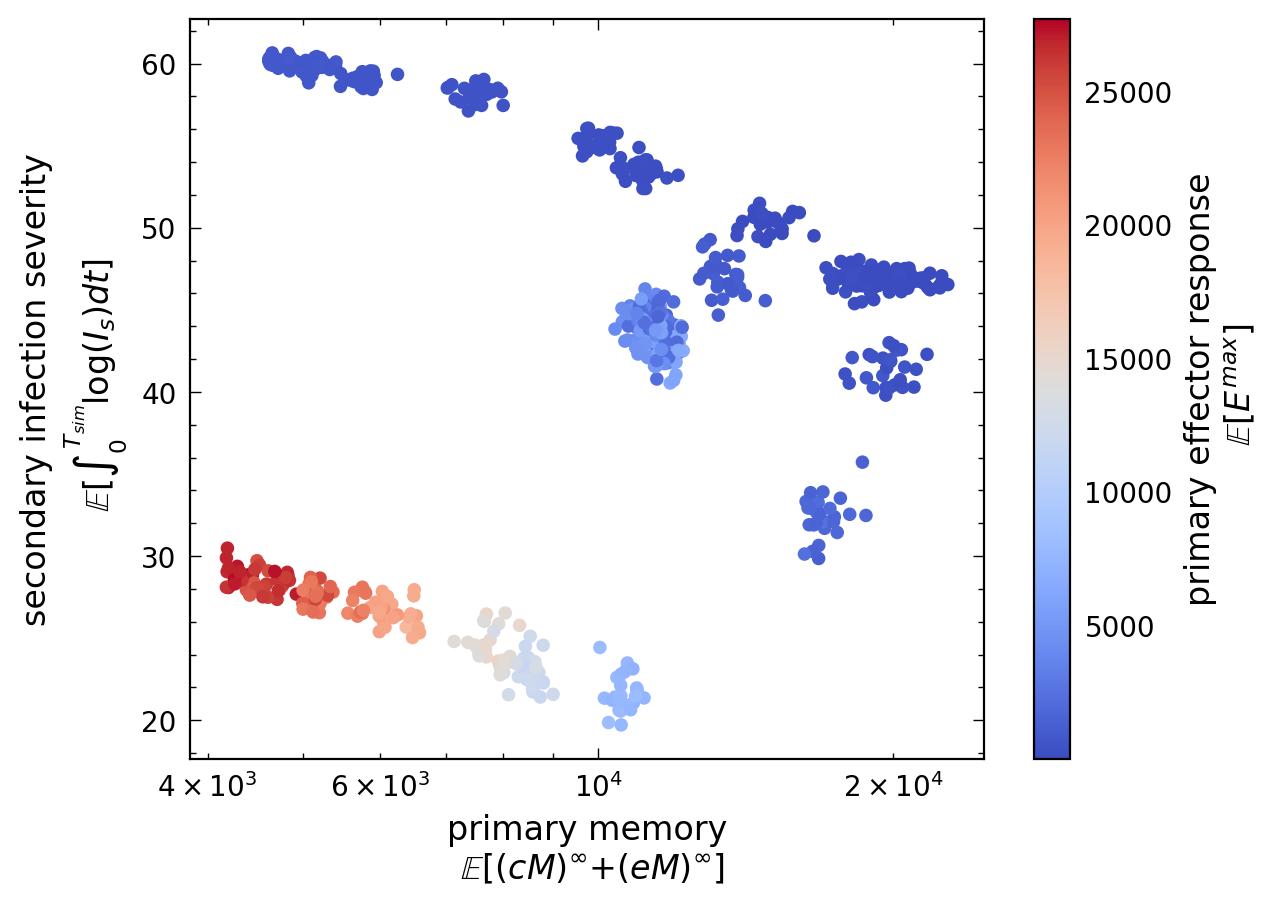

In [24]:
p_harm = full_net_data['p_p_harm']
s_harm = full_net_data['s_s_harm']
p_max_eff = full_net_data['p_max_E']
s_mem = full_net_data['s_inf_cM']
p_mem = full_net_data['p_inf_cM'] + full_net_data['p_inf_eM']
low, high = 10, 160
mean_thresh = 1500

plt.scatter(p_mem, s_harm, 
            c = p_max_eff, cmap='coolwarm', s = 15)
plt.colorbar(label ="primary effector response\n $\mathbb{E}[$"+stat_names[13]+r"$]$")

plt.xlabel("primary memory\n $\mathbb{E}[$"+stat_names[-4]+"+"+stat_names[-1]+r"$]$")
plt.ylabel("secondary infection severity\n $\mathbb{E}[$"+stat_names[-7]+r"$]$")
plt.semilogx()
plt.savefig('_figs/p_mem_v_s_harm_w_p_eff'+'.png', dpi=300, bbox_inches="tight")

Additionally, the fold change reduction in severity increases with the amount of memory formed during a primary infection for all networks. This makes sense given the trade-off between effectiveness and memory formation observed for the most effective networks. Notably, the fold change reduction is lowest for the networks that produce the most effector.

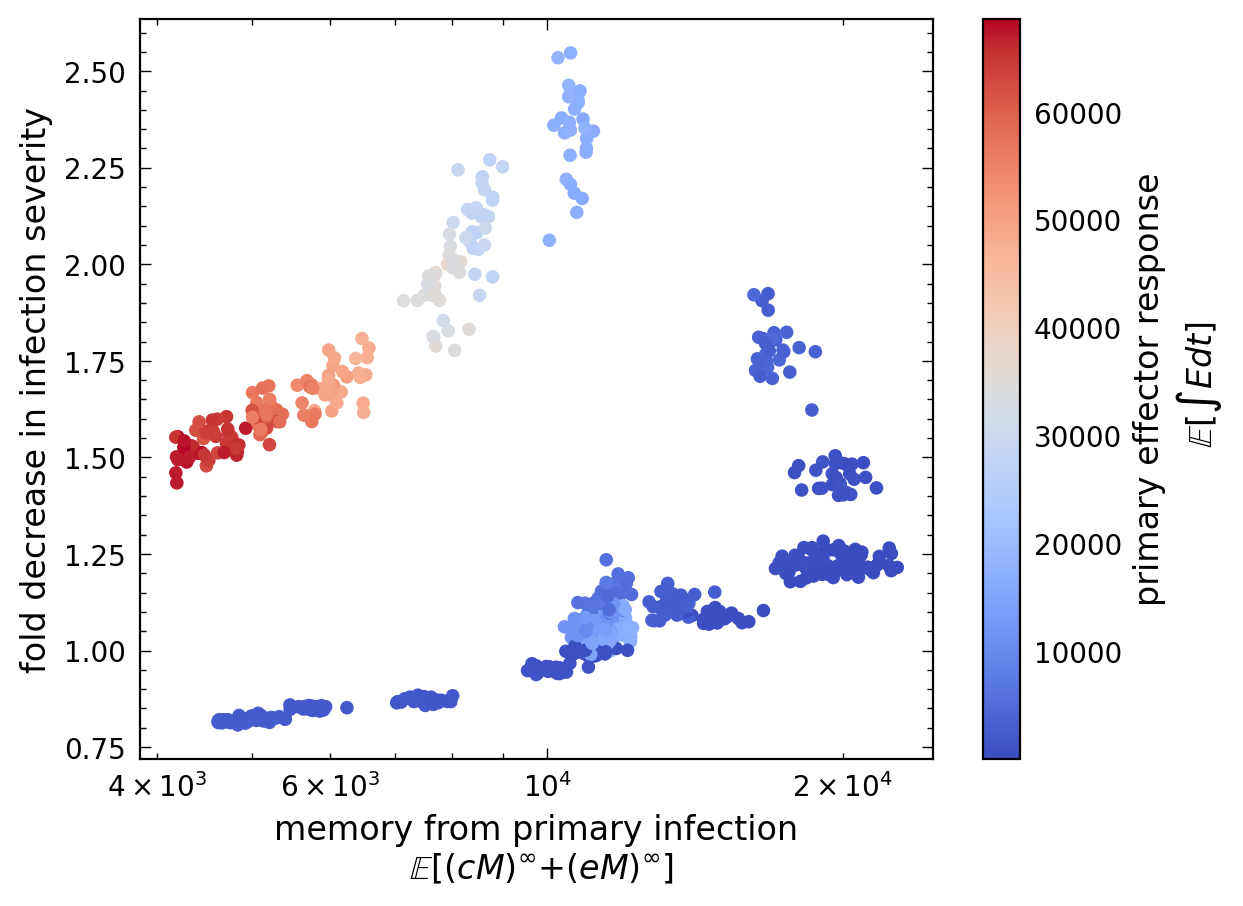

In [25]:
p_harm = full_net_data['s_p_harm']
s_harm = full_net_data['s_s_harm']
p_max_eff = full_net_data['p_max_E']
s_mem = full_net_data['s_inf_cM'] + full_net_data['s_inf_eM']
p_mem = full_net_data['p_inf_eM'] + full_net_data['p_inf_cM']
fld_chg = p_harm/s_harm
low, high = 10, 160

plt.scatter(p_mem, fld_chg, 
            c = p_int_eff, cmap='coolwarm', s = 15)
plt.colorbar(label ="primary effector response\n $\mathbb{E}[$"+stat_names[16]+r"$]$")

plt.xlabel("memory from primary infection\n $\mathbb{E}[$"+stat_names[-4]+"+"+stat_names[-1]+r"$]$")
plt.ylabel("fold decrease in infection severity")
plt.semilogx()
plt.savefig('_figs/p_mem_v_fld_change_w_p_eff'+'.png', dpi=300, bbox_inches="tight")

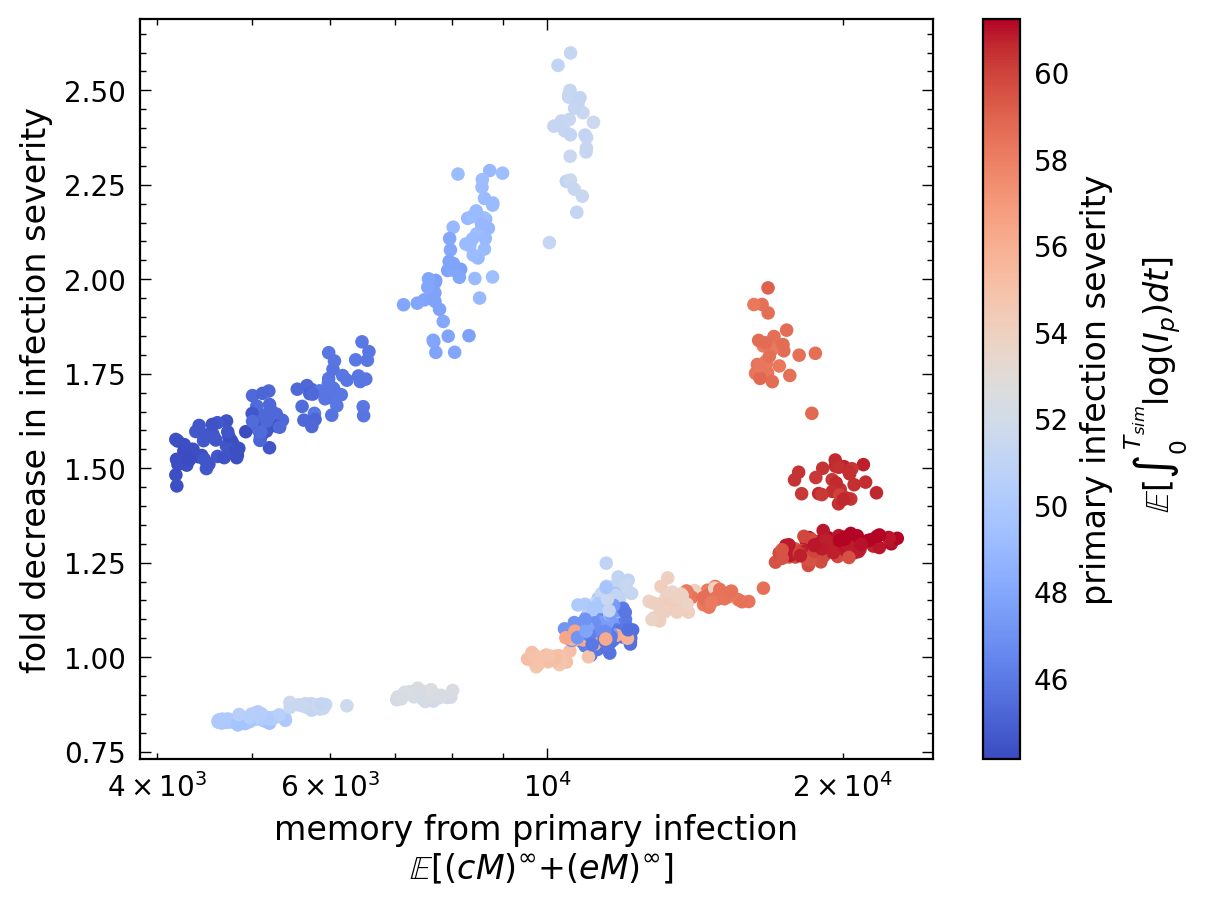

In [26]:
p_harm = full_net_data['p_p_harm']
s_harm = full_net_data['s_s_harm']
p_max_eff = full_net_data['p_max_E']
s_mem = full_net_data['s_inf_cM'] + full_net_data['s_inf_eM']
p_mem = full_net_data['p_inf_eM'] + full_net_data['p_inf_cM']
fld_chg = p_harm/s_harm
low, high = 10, 160

plt.scatter(p_mem, fld_chg, 
            c = p_harm, cmap='coolwarm', s = 15)
plt.colorbar(label ="primary infection severity\n $\mathbb{E}[$"+stat_names[10]+r"$]$")

plt.xlabel("memory from primary infection\n $\mathbb{E}[$"+stat_names[-4]+"+"+stat_names[-1]+r"$]$")
plt.ylabel("fold decrease in infection severity")
plt.semilogx()

plt.savefig('_figs/p_mem_v_fld_change_w_p_harm'+'.png', dpi=300, bbox_inches="tight")

#### Ranking feasible networks for anticipation reveals temporal bet hedging
First we look at the cumulative severity incurred by a network. Networks that minimize cumulative severity initially hedge their bets by not committing fully to either an effector or memory response, but have a strong bias for effector production in the later stages of an infection. The worst networks initially make a strong commitment to effector response, and over-commit to memory formation in the later stages of the infection. The lesson is that you want to make some memory early, focus on effector response later, and store some memory if you can at the end.

We consider the networks whose primary severity is less than the minimum cumulative severity over all networks. Ranking these networks based on the fold change reduction in severity shows that the most anticipatory initially commit to memory production, while in the latter stages of the infection they priotitize effector formation to clear the infection. Importantly, they also use antigen and cytokine signals to commit primary memory to effector production during a secondary response. The least anticipatory networks appear to commit more fully to an initial effector response.

/tmp/ipykernel_12588/741322053.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eff_nets['cumu_harm'] = eff_nets['s_p_harm']+eff_nets['s_s_harm']
/tmp/ipykernel_12588/741322053.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eff_nets.sort_values(by=['cumu_harm'], ascending=True, inplace=True)


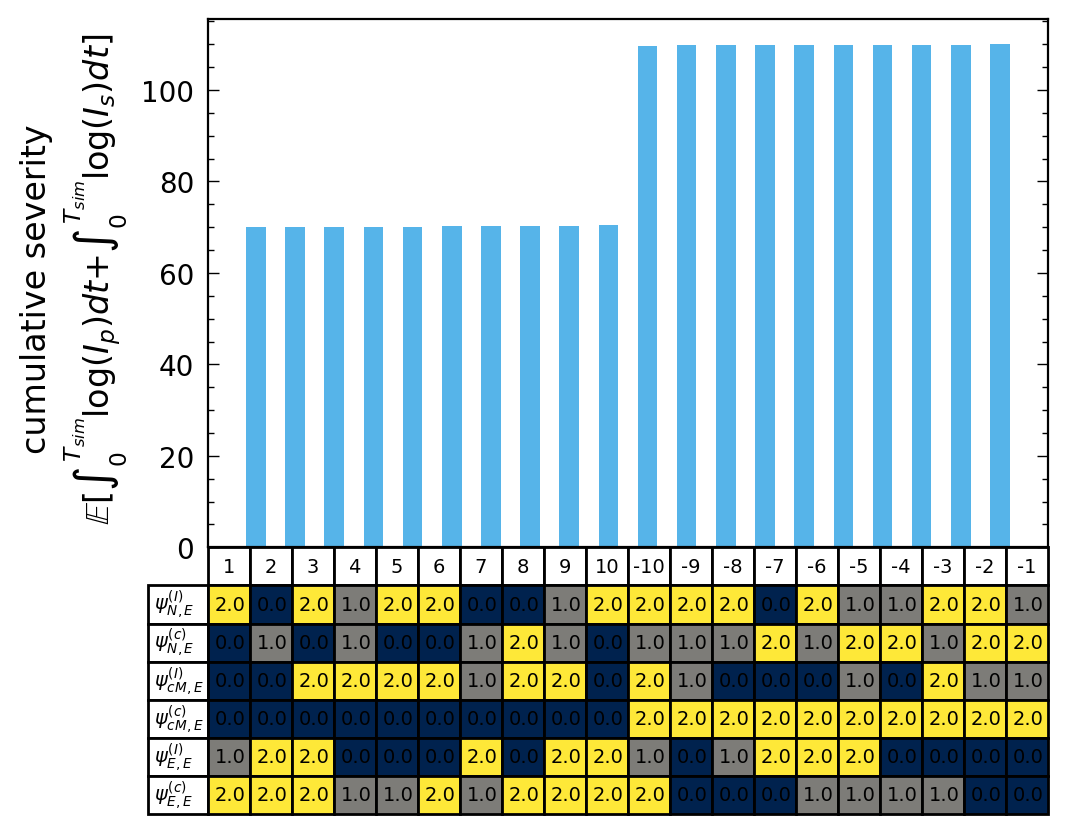

In [27]:
# plot ranking of networks based on cumulative severity: 
low, high = 10, 160
eff_nets = full_net_data.loc[full_net_data.p_int_E >= low]
eff_nets['cumu_harm'] = eff_nets['s_p_harm']+eff_nets['s_s_harm']
eff_nets.sort_values(by=['cumu_harm'], ascending=True, inplace=True)

cumu_harm = eff_nets['cumu_harm'].to_numpy()

plt.figure(figsize=(6,3))  
r = np.arange(20)
width = 0.5
opt_regs = np.round_(np.vstack(((eff_nets.to_numpy())[:10,0:6], (eff_nets.to_numpy())[-11:-1,0:6])),2).T
norm = plt.Normalize(opt_regs.min(), opt_regs.max())
colours = plt.cm.cividis(norm(opt_regs))

plt.bar(r, np.append(cumu_harm[0:10], cumu_harm[-11:-1], axis = 0), width = width, label = r'vary $N_0$')

the_table = plt.table(cellText= opt_regs,
                      rowLabels=[r"$\psi_{N,E}^{(I)}$", r"$\psi_{N,E}^{(c)}$", r"$\psi_{cM,E}^{(I)}$", r"$\psi_{cM,E}^{(c)}$", r"$\psi_{E,E}^{(I)}$", r"$\psi_{E,E}^{(c)}$"],
                      colLabels=[1,2,3,4,5,6,7,8,9,10,-10,-9,-8,-7,-6, -5, -4, -3,-2,-1],
                      loc='bottom',
                      cellColours = colours)

plt.subplots_adjust(left=0.2, bottom=0.0)
#plt.ylabel( r"$I($"+stat_names[16]+r";$N_0)$", fontsize = 16)
plt.ylabel("cumulative severity \n $\mathbb{E}[$"+stat_names[-9]+r"+"+stat_names[-7]+r"$]$", fontsize = 12)
#plt.xlabel('rank', fontsize = 16)
plt.xticks([])

plt.savefig('_figs/rank_cumu_harm'+'.png', dpi=300, bbox_inches="tight")

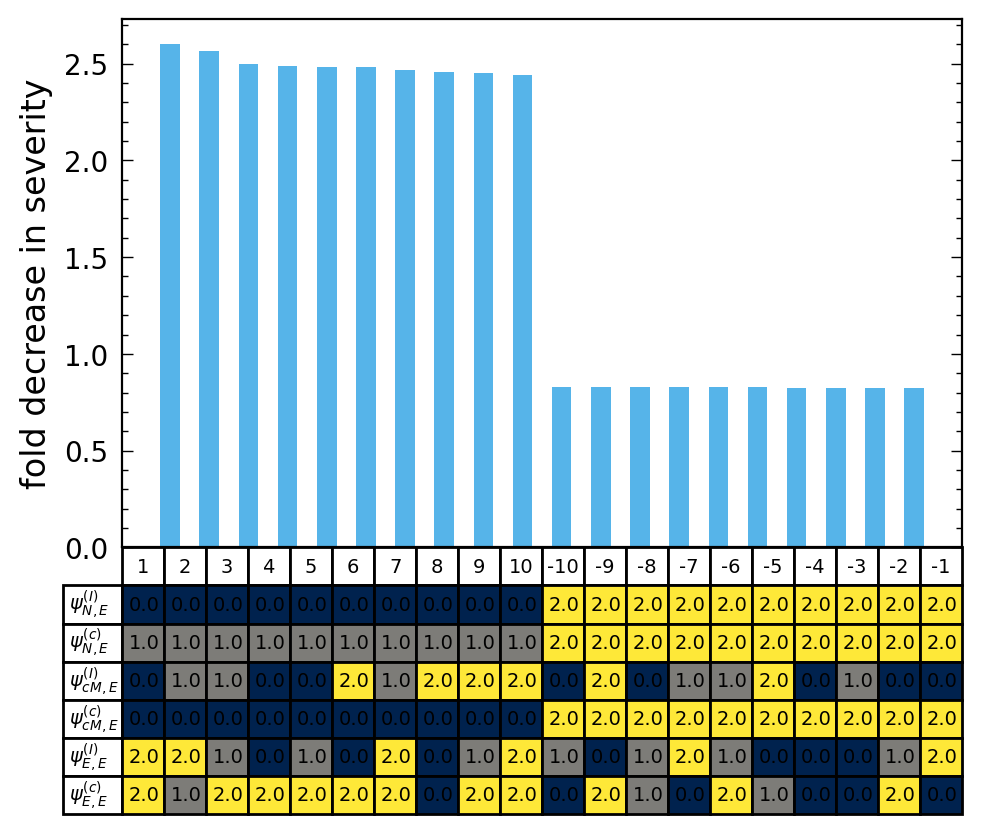

In [28]:
# plot ranking of networks based on anticipation: 
low, high = 10, np.min(full_net_data['p_p_harm']+full_net_data['s_s_harm'])
eff_nets = full_net_data.loc[full_net_data.p_p_harm <= high]
eff_nets['ps_f_cng'] = eff_nets['p_p_harm']/eff_nets['s_s_harm']
eff_nets.sort_values(by=['ps_f_cng'], ascending=False, inplace=True)

ps_f_cng = eff_nets['ps_f_cng'].to_numpy()

plt.figure(figsize=(6,3))  
r = np.arange(20)
width = 0.5
opt_regs = np.round_(np.vstack(((eff_nets.to_numpy())[:10,0:6], (eff_nets.to_numpy())[-11:-1,0:6])),2).T
norm = plt.Normalize(opt_regs.min(), opt_regs.max())
colours = plt.cm.cividis(norm(opt_regs))

plt.bar(r, np.append(ps_f_cng[0:10], ps_f_cng[-11:-1], axis = 0), width = width, label = r'vary $N_0$')

the_table = plt.table(cellText= opt_regs,
                      rowLabels=[r"$\psi_{N,E}^{(I)}$", r"$\psi_{N,E}^{(c)}$", r"$\psi_{cM,E}^{(I)}$", r"$\psi_{cM,E}^{(c)}$", r"$\psi_{E,E}^{(I)}$", r"$\psi_{E,E}^{(c)}$"],
                      colLabels=[1,2,3,4,5,6,7,8,9,10,-10,-9,-8,-7,-6, -5, -4, -3,-2,-1],
                      loc='bottom',
                      cellColours = colours)

plt.subplots_adjust(left=0.2, bottom=0.0)
#plt.ylabel( r"$I($"+stat_names[16]+r";$N_0)$", fontsize = 16)
plt.ylabel("fold decrease in severity", fontsize = 12)
#plt.xlabel('rank', fontsize = 16)
plt.xticks([])

plt.savefig('_figs/rank_fld_chg'+'.png', dpi=300, bbox_inches="tight")

Do the most anticipatory networks pay a clear price in terms of primary severity incurred? Indicated in star is a very promising network. This same network is actually one of the ones that minimizes cumulative cost.

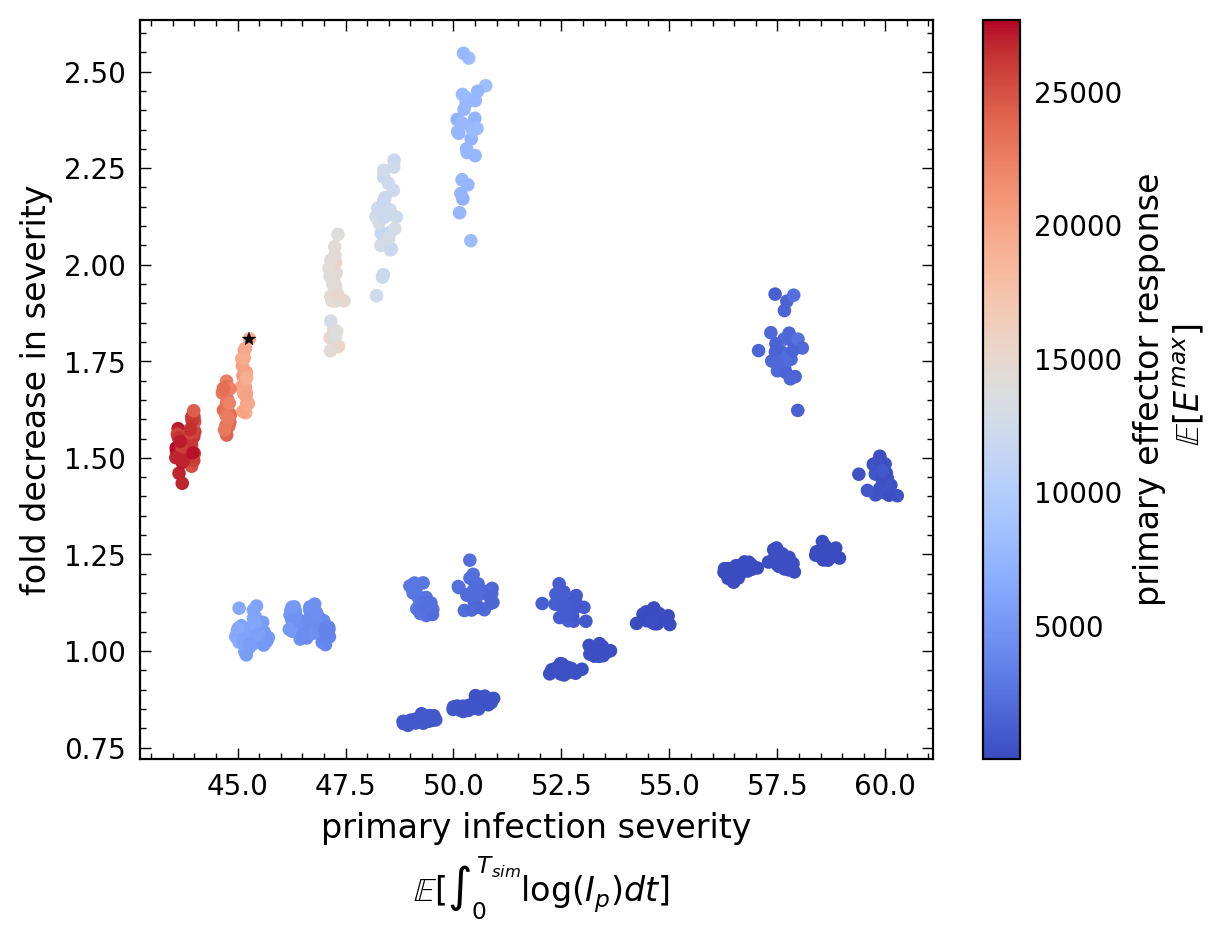

In [29]:
p_harm = full_net_data['s_p_harm']
s_harm = full_net_data['s_s_harm']
p_max_eff = full_net_data['p_max_E']
fld_chg = p_harm/s_harm
low, high = 10, np.min(p_harm + s_harm)

plt.scatter(p_harm[(p_harm <= high)], fld_chg[(p_harm <= high)], 
            c = p_max_eff[(p_harm <= high)], cmap='coolwarm', s = 15)
plt.colorbar(label ="primary effector response\n $\mathbb{E}[$"+stat_names[13]+r"$]$")

y_best = np.max(fld_chg[p_harm <= 0.65*high])
x_best = p_harm[fld_chg == y_best]

plt.plot(x_best, y_best, 'k*')

plt.ylabel("fold decrease in severity")
plt.xlabel("primary infection severity\n $\mathbb{E}[$"+stat_names[-9]+r"$]$")

plt.savefig('_figs/p_harm_v_fld_chg_feasible'+'.png', dpi=300, bbox_inches="tight")

### Multi-Objective Optimization: looking at the Pareto front
Through this entire analysis, no clear winner emerges and networks must make trade-offs between different performance measures. For example, the networks that minimize primary infection severity do not also strictly minimize secondary infection severity (although they might minimize cumulative severity). Interestingly while there is a clear trade-off between cumulative severity and accuracy w.r.t. antigenicity, no trade-off exists between severity and virulence.

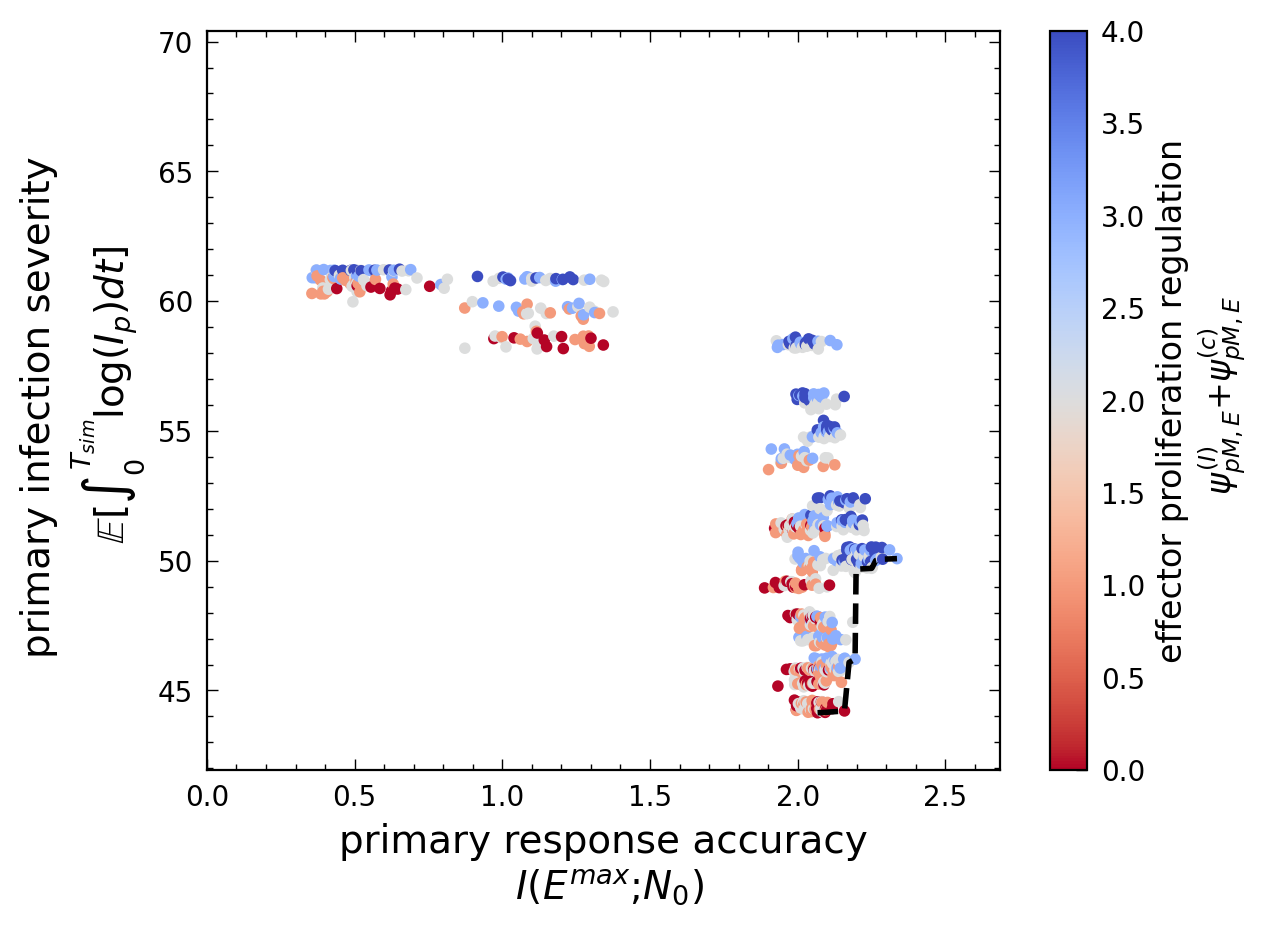

In [30]:
#z = (full_net_data['s_max_E'] + full_net_data['s_inf_cM'] + full_net_data['s_inf_eM']).to_numpy()
z = 0*full_net_data['p_psi_NE_c'] + full_net_data['p_psi_EeM_c'] + full_net_data['p_psi_EeM_I']
y = ((full_net_data['p_p_harm'] + 0*full_net_data['s_s_harm']).to_numpy())
x = (full_net_data['p_mi_N_0_max_E'].to_numpy())
xyz = (np.array([x , y, z]).T)[x.argsort()]

plt.scatter(xyz[:,0], xyz[:,1],
           c = xyz[:,2], cmap= plt.cm.coolwarm_r, s = 10)

plt.colorbar(label ="effector proliferation regulation\n "+stat_names[4]+"+"+stat_names[5])#+"+"+stat_names[5])

# find pareto front
remove_row = np.ones(xyz.shape[0], dtype = bool)

for j in np.arange(len(xyz[:,0])):
    for k in np.arange(len(xyz[:,0])):
        if xyz[j,0] < xyz[k,0] and xyz[j,1] > xyz[k,1]:
            remove_row[j] = False


x_front = (xyz[:,0])[remove_row,...]
y_front = (xyz[:,1])[remove_row,...]
#ax.scatter(x_front, y_front, c='#252525')
plt.plot(x_front, y_front, 'k--', linewidth=2)

plt.axis([0.0, np.max(xyz[:,0])*1.15, 0.95*np.min(xyz[:,1]), np.max(xyz[:,1])*1.15])
plt.xlabel("primary response accuracy\n "+r"$I($"+stat_names[13]+r";$N_0)$", fontsize = 14)
plt.ylabel("primary infection severity \n $\mathbb{E}[$"+stat_names[-9]+r"$]$", fontsize = 14)

plt.savefig('_figs/pareto_p_sens_N_0_v_p_harm_w_EE_regs'+'.png', dpi=300, bbox_inches="tight")

In [31]:
low, high = 0, 160
eff_nets = full_net_data.loc[full_net_data.p_int_E >= low]
eff_nets.sort_values(by=['p_mi_N_0_max_E'], ascending=False, inplace=True)

print((eff_nets.to_numpy())[0:50,0:6])

[[2. 2. 1. 2. 1. 1.]
 [1. 2. 1. 2. 0. 1.]
 [2. 2. 2. 2. 1. 1.]
 [1. 2. 2. 2. 1. 2.]
 [1. 2. 0. 2. 0. 1.]
 [2. 2. 1. 2. 1. 0.]
 [1. 2. 2. 2. 0. 1.]
 [2. 2. 1. 2. 2. 1.]
 [1. 2. 2. 2. 1. 1.]
 [2. 2. 0. 2. 0. 1.]
 [2. 2. 0. 2. 2. 1.]
 [1. 2. 2. 2. 0. 2.]
 [2. 2. 2. 2. 1. 2.]
 [1. 2. 1. 2. 2. 2.]
 [1. 2. 0. 2. 2. 1.]
 [2. 2. 1. 2. 0. 0.]
 [2. 2. 2. 2. 2. 0.]
 [2. 2. 0. 2. 2. 2.]
 [2. 2. 1. 2. 0. 1.]
 [0. 2. 2. 2. 1. 0.]
 [1. 2. 1. 2. 1. 0.]
 [1. 2. 0. 2. 0. 2.]
 [2. 1. 0. 2. 2. 1.]
 [2. 2. 1. 2. 2. 2.]
 [2. 2. 1. 2. 0. 2.]
 [2. 1. 0. 2. 0. 0.]
 [2. 1. 2. 2. 2. 2.]
 [1. 2. 2. 2. 0. 0.]
 [2. 2. 1. 2. 2. 0.]
 [2. 2. 0. 2. 1. 1.]
 [0. 2. 0. 2. 0. 0.]
 [2. 1. 1. 2. 0. 0.]
 [0. 2. 0. 2. 2. 1.]
 [1. 2. 0. 2. 2. 2.]
 [2. 1. 2. 2. 0. 2.]
 [2. 2. 2. 2. 0. 2.]
 [2. 2. 2. 2. 0. 1.]
 [1. 2. 1. 2. 1. 1.]
 [1. 2. 1. 2. 0. 0.]
 [1. 2. 1. 2. 2. 1.]
 [2. 1. 0. 2. 0. 1.]
 [2. 2. 2. 2. 2. 2.]
 [2. 1. 0. 2. 1. 1.]
 [1. 2. 0. 2. 1. 2.]
 [2. 2. 0. 2. 2. 0.]
 [1. 2. 1. 2. 0. 2.]
 [1. 2. 2. 1. 2. 2.]
 [2. 2. 0. 2.

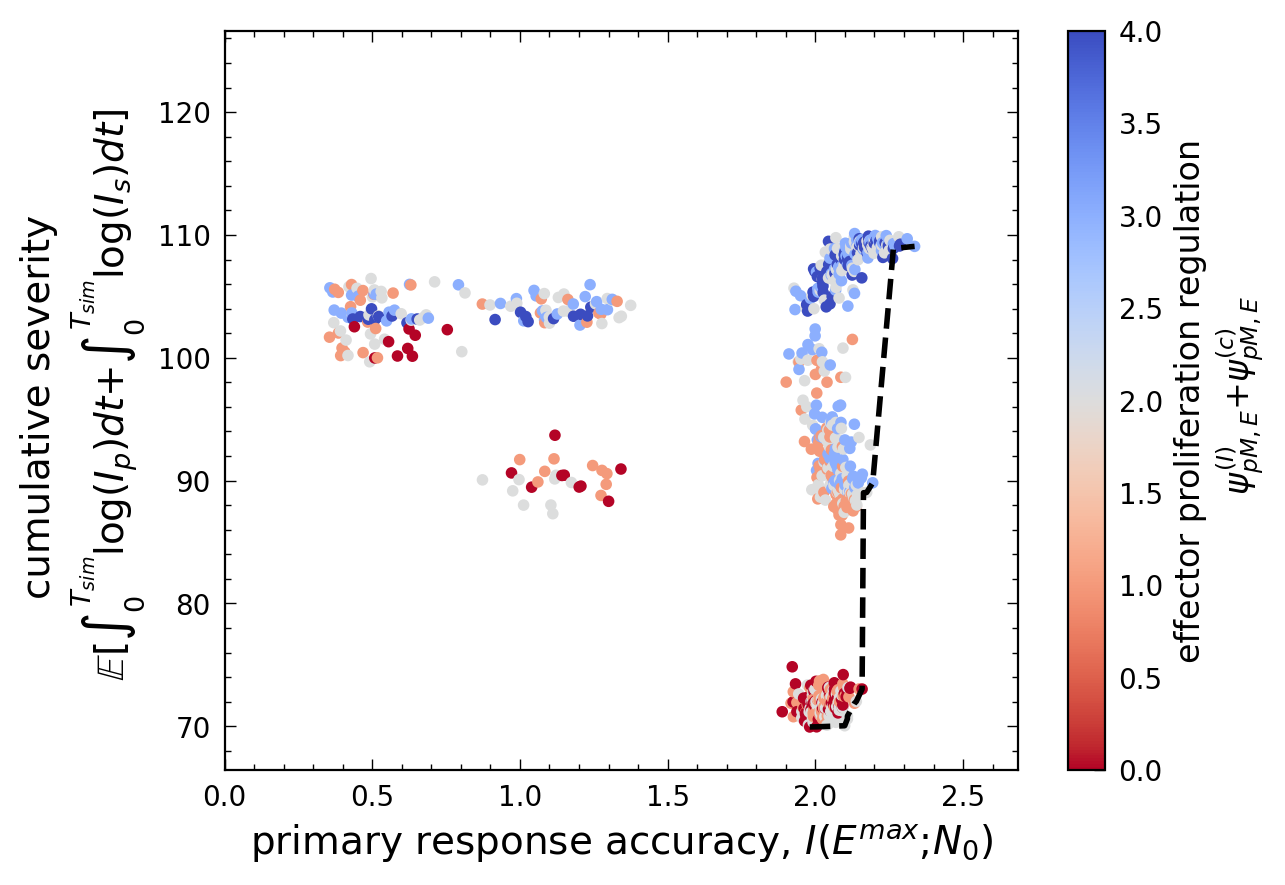

In [32]:
#z = (full_net_data['s_max_E'] + full_net_data['s_inf_cM'] + full_net_data['s_inf_eM']).to_numpy()
z = 0*full_net_data['s_psi_NE_c'] + full_net_data['s_psi_EeM_c'] + full_net_data['s_psi_EeM_I']
y = ((full_net_data['s_p_harm'] + full_net_data['s_s_harm']).to_numpy())
x = (full_net_data['p_mi_N_0_max_E'].to_numpy())
xyz = (np.array([x , y, z]).T)[x.argsort()]

plt.scatter(xyz[:,0], xyz[:,1],
           c = xyz[:,2], cmap=plt.cm.coolwarm_r, s = 10)

plt.colorbar(label ="effector proliferation regulation\n "+stat_names[4]+"+"+stat_names[5])#+"+"+stat_names[5])

# find pareto front
remove_row = np.ones(xyz.shape[0], dtype = bool)

for j in np.arange(len(xyz[:,0])):
    for k in np.arange(len(xyz[:,0])):
        if xyz[j,0] < xyz[k,0] and xyz[j,1] > xyz[k,1]:
            remove_row[j] = False


x_front = (xyz[:,0])[remove_row,...]
y_front = (xyz[:,1])[remove_row,...]
#ax.scatter(x_front, y_front, c='#252525')
plt.plot(x_front, y_front, 'k--', linewidth=2)

plt.axis([0.0, np.max(xyz[:,0])*1.15, 0.95*np.min(xyz[:,1]), np.max(xyz[:,1])*1.15])
plt.xlabel(r"primary response accuracy, "+r"$I($"+stat_names[13]+r";$N_0)$", fontsize = 14)
plt.ylabel("cumulative severity \n $\mathbb{E}[$"+stat_names[-9]+r"+"+stat_names[-7]+r"$]$", fontsize = 14)

plt.savefig('_figs/pareto_p_sens_N_0_v_cumu_harm_w_EE_regs'+'.png', dpi=300, bbox_inches="tight")

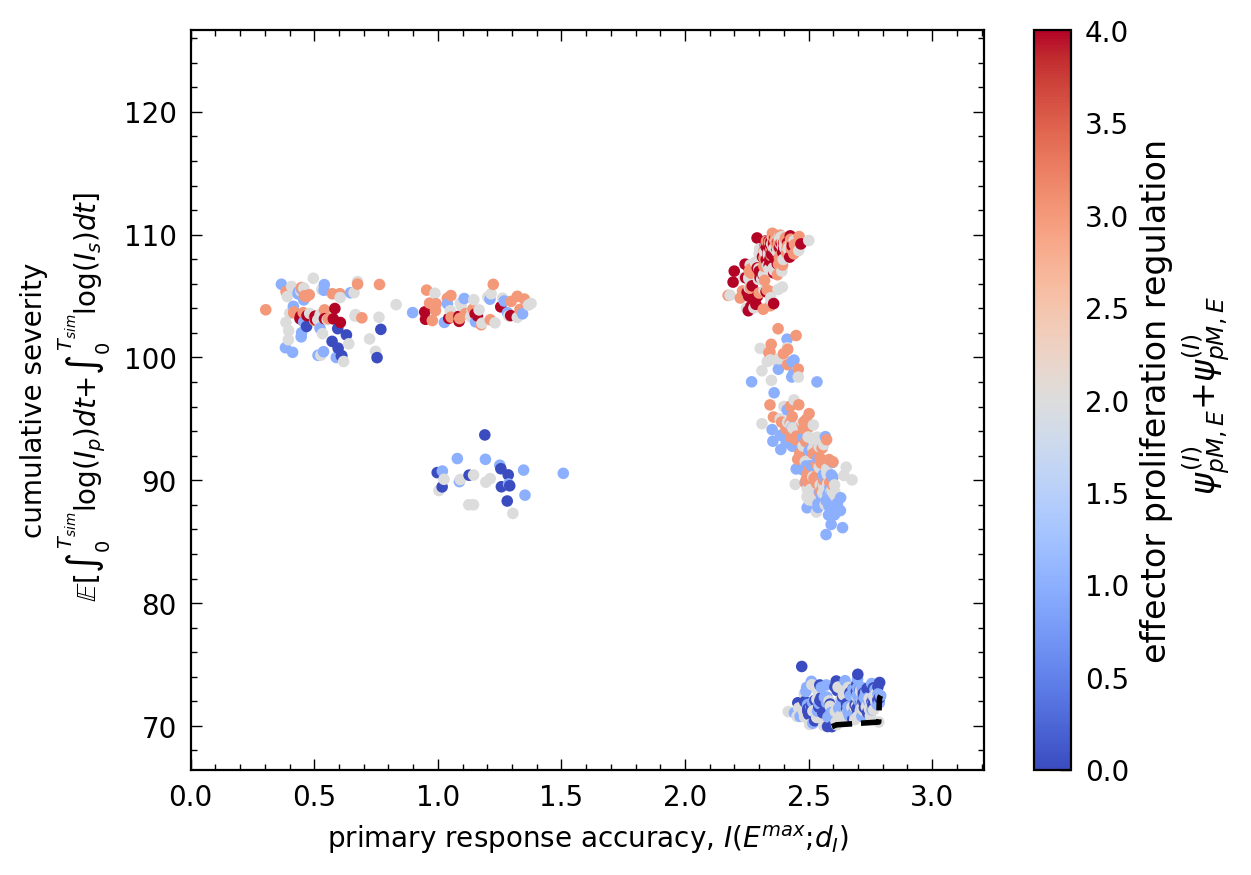

In [33]:
#z = (full_net_data['s_max_E'] + full_net_data['s_inf_cM'] + full_net_data['s_inf_eM']).to_numpy()
z = full_net_data['s_psi_EeM_c'] + full_net_data['s_psi_EeM_I'] + 0*full_net_data['s_max_E']
y = ((full_net_data['s_p_harm'] + full_net_data['s_s_harm']).to_numpy())
x = (full_net_data['p_mi_d_I_max_E'].to_numpy())
xyz = (np.array([x , y, z]).T)[x.argsort()]

plt.scatter(xyz[:,0], xyz[:,1],
           c = xyz[:,2], cmap='coolwarm',s = 10)

plt.colorbar(label ="effector proliferation regulation\n "+stat_names[4]+"+"+stat_names[4])#+"+"+stat_names[5])

# find pareto front
remove_row = np.ones(xyz.shape[0], dtype = bool)

for j in np.arange(len(xyz[:,0])):
    for k in np.arange(len(xyz[:,0])):
        if xyz[j,0] < xyz[k,0] and xyz[j,1] > xyz[k,1]:
            remove_row[j] = False


x_front = (xyz[:,0])[remove_row,...]
y_front = (xyz[:,1])[remove_row,...]
#ax.scatter(x_front, y_front, c='#252525')
plt.plot(x_front, y_front, 'k--', linewidth=2)

plt.axis([0.0, np.max(xyz[:,0])*1.15, 0.95*np.min(xyz[:,1]), np.max(xyz[:,1])*1.15])
plt.xlabel(r"primary response accuracy, "+r"$I($"+stat_names[13]+r";$d_I)$", fontsize = 10)
plt.ylabel("cumulative severity\n $\mathbb{E}[$"+stat_names[-9]+r"+"+stat_names[-7]+r"$]$", fontsize = 10)

plt.savefig('_figs/pareto_p_sens_bI_v_cumu_harm_w_w_EE_regs'+'.png', dpi=300, bbox_inches="tight")

/tmp/ipykernel_12588/4919137.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eff_nets['cumu_harm'] = eff_nets['s_p_harm']+eff_nets['s_s_harm']
/tmp/ipykernel_12588/4919137.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eff_nets.sort_values(by=['cumu_harm'], ascending=True, inplace=True)


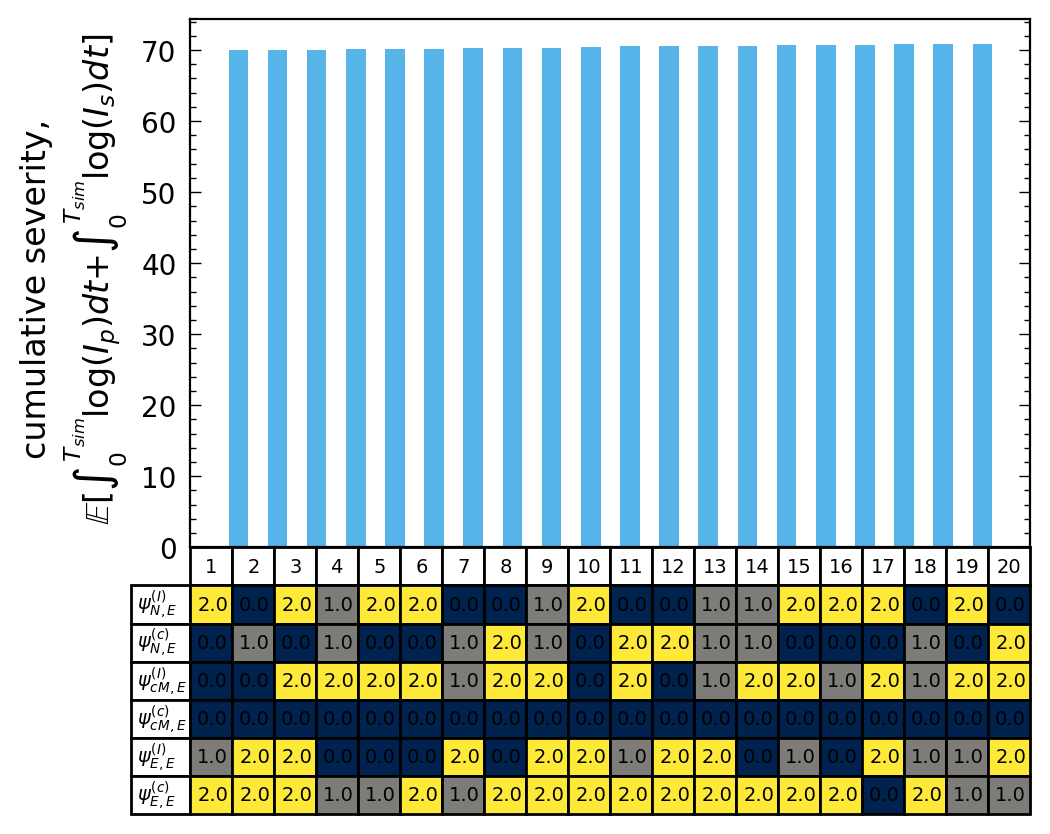

In [34]:
# plot ranking of networks based on cumulative severity: 
low, high = 10, 160
eff_nets = full_net_data.loc[full_net_data.p_max_E >= low]
eff_nets['cumu_harm'] = eff_nets['s_p_harm']+eff_nets['s_s_harm']
eff_nets.sort_values(by=['cumu_harm'], ascending=True, inplace=True)

cumu_harm = eff_nets['cumu_harm'].to_numpy()

plt.figure(figsize=(6,3))  
r = np.arange(20)
width = 0.5
opt_regs = np.round_((eff_nets.to_numpy())[:20,0:6],2).T
norm = plt.Normalize(opt_regs.min(), opt_regs.max())
colours = plt.cm.cividis(norm(opt_regs))

plt.bar(r, cumu_harm[0:20], width = width, label = r'vary $N_0$')

the_table = plt.table(cellText= opt_regs,
                      rowLabels=[r"$\psi_{N,E}^{(I)}$", r"$\psi_{N,E}^{(c)}$", r"$\psi_{cM,E}^{(I)}$", r"$\psi_{cM,E}^{(c)}$", r"$\psi_{E,E}^{(I)}$", r"$\psi_{E,E}^{(c)}$"],
                      colLabels=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
                      loc='bottom',
                      cellColours = colours)

plt.subplots_adjust(left=0.2, bottom=0.0)
#plt.ylabel( r"$I($"+stat_names[16]+r";$N_0)$", fontsize = 16)
plt.ylabel("cumulative severity, \n $\mathbb{E}[$"+stat_names[-9]+r"+"+stat_names[-7]+r"$]$", fontsize = 12)
#plt.xlabel('rank', fontsize = 16)
plt.xticks([])

plt.savefig('_figs/rank_cumu_harm_topn'+'.png', dpi=300, bbox_inches="tight")

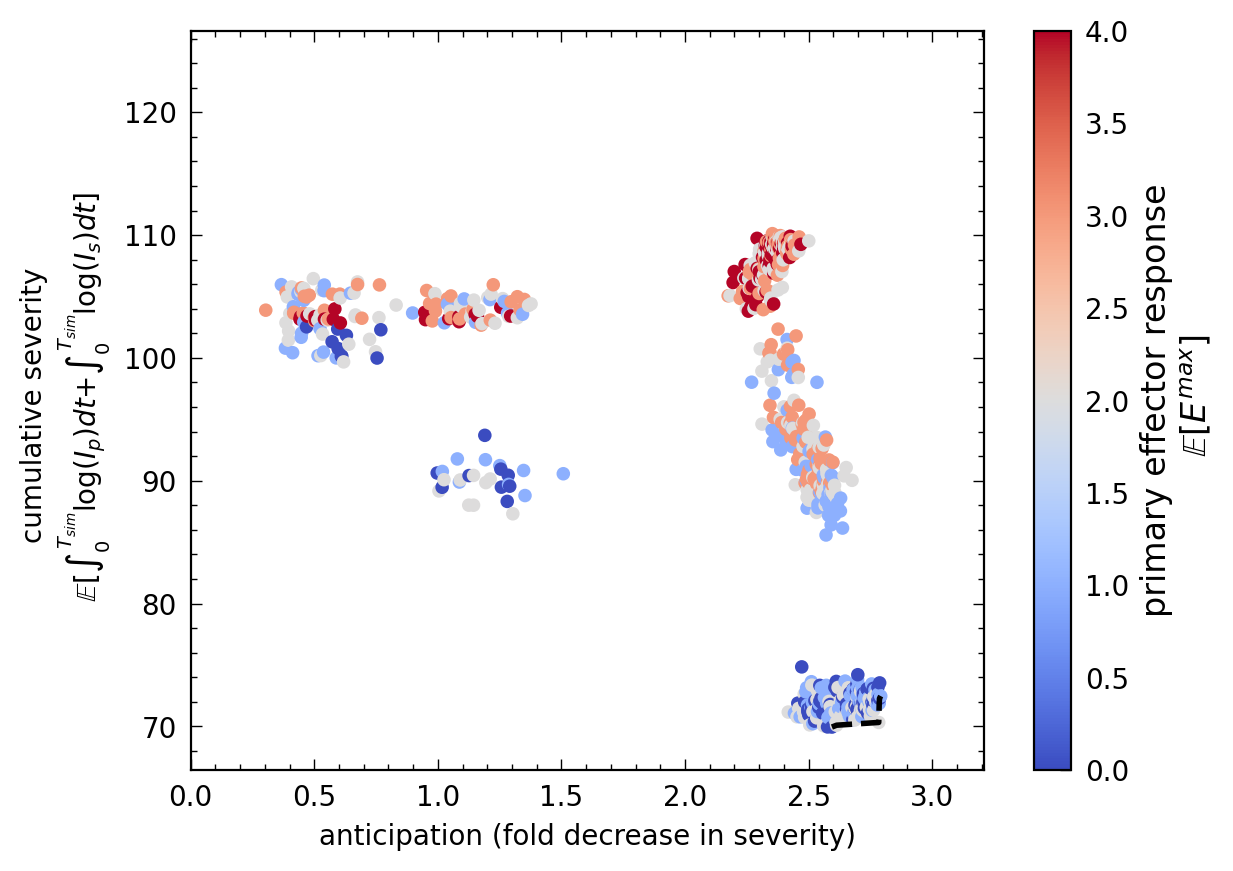

In [35]:
x = (full_net_data['s_p_harm'].to_numpy())/(full_net_data['s_s_harm'].to_numpy())
y = (full_net_data['s_p_harm'].to_numpy())+(full_net_data['s_s_harm'].to_numpy())
z = full_net_data['p_max_E'].to_numpy()
xy = (np.array([x , y,z]).T)[x.argsort()]

plt.scatter(xyz[:,0], xyz[:,1],
           c = xyz[:,2], cmap='coolwarm', s = 15)

plt.colorbar(label ="primary effector response\n $\mathbb{E}[$"+stat_names[13]+r"$]$")

# find pareto front
remove_row = np.ones(xyz.shape[0], dtype = bool)

for j in np.arange(len(xyz[:,0])):
    for k in np.arange(len(xyz[:,0])):
        if xyz[j,0] < xyz[k,0] and xyz[j,1] > xyz[k,1]:
            remove_row[j] = False


x_front = (xyz[:,0])[remove_row,...]
y_front = (xyz[:,1])[remove_row,...]
#ax.scatter(x_front, y_front, c='#252525')
plt.plot(x_front, y_front, 'k--', linewidth=2)

plt.axis([0.0, np.max(xyz[:,0])*1.15, 0.95*np.min(xyz[:,1]), np.max(xyz[:,1])*1.15])
plt.xlabel(r"anticipation (fold decrease in severity)", fontsize = 10)
plt.ylabel("cumulative severity \n $\mathbb{E}[$"+stat_names[-9]+r"+"+stat_names[-7]+r"$]$", fontsize = 10)

plt.savefig('_figs/pareto_fld_chg_v_cumu_harm_w_p_eff'+'.png', dpi=300, bbox_inches="tight")

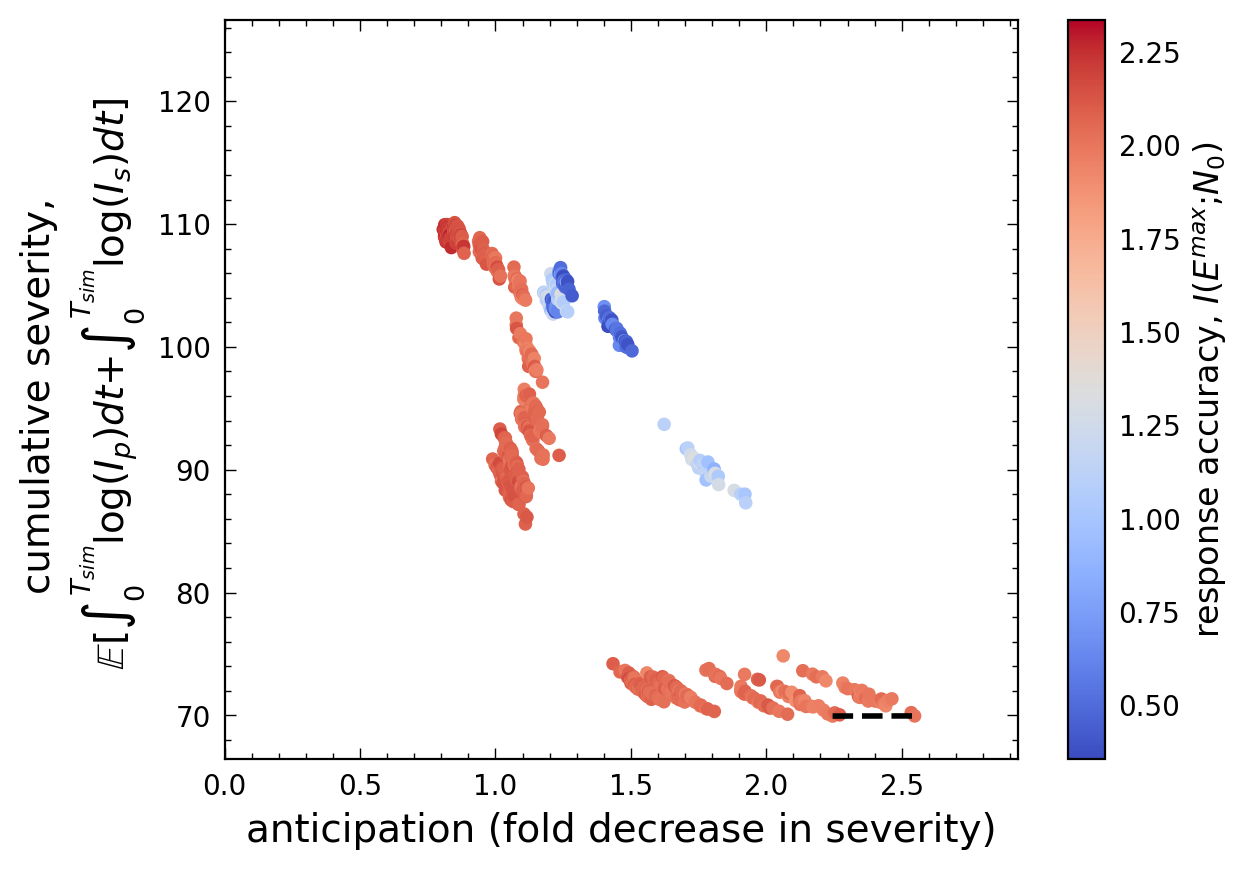

In [36]:
x = (full_net_data['s_p_harm'].to_numpy())/(full_net_data['s_s_harm'].to_numpy())
y = (full_net_data['s_p_harm'].to_numpy())+(full_net_data['s_s_harm'].to_numpy())
z = full_net_data['p_mi_N_0_max_E'].to_numpy()
xyz = (np.array([x , y,z]).T)[x.argsort()]

plt.scatter(xyz[:,0], xyz[:,1],
           c = xyz[:,2], cmap='coolwarm', s = 15)

plt.colorbar(label =r"response accuracy, "+r"$I($"+stat_names[13]+r";$N_0)$")

# find pareto front
remove_row = np.ones(xyz.shape[0], dtype = bool)

for j in np.arange(len(xyz[:,0])):
    for k in np.arange(len(xyz[:,0])):
        if xyz[j,0] < xyz[k,0] and xyz[j,1] > xyz[k,1]:
            remove_row[j] = False


x_front = (xyz[:,0])[remove_row,...]
y_front = (xyz[:,1])[remove_row,...]
#ax.scatter(x_front, y_front, c='#252525')
plt.plot(x_front, y_front, 'k--', linewidth=2)

plt.axis([0.0, np.max(xyz[:,0])*1.15, 0.95*np.min(xyz[:,1]), np.max(xyz[:,1])*1.15])
plt.xlabel(r"anticipation (fold decrease in severity)", fontsize = 14)
plt.ylabel("cumulative severity, \n $\mathbb{E}[$"+stat_names[-9]+r"+"+stat_names[-7]+r"$]$", fontsize = 14)

plt.savefig('_figs/pareto_fld_chg_v_cumu_harm_w_p_sens_N_0'+'.png', dpi=300, bbox_inches="tight")

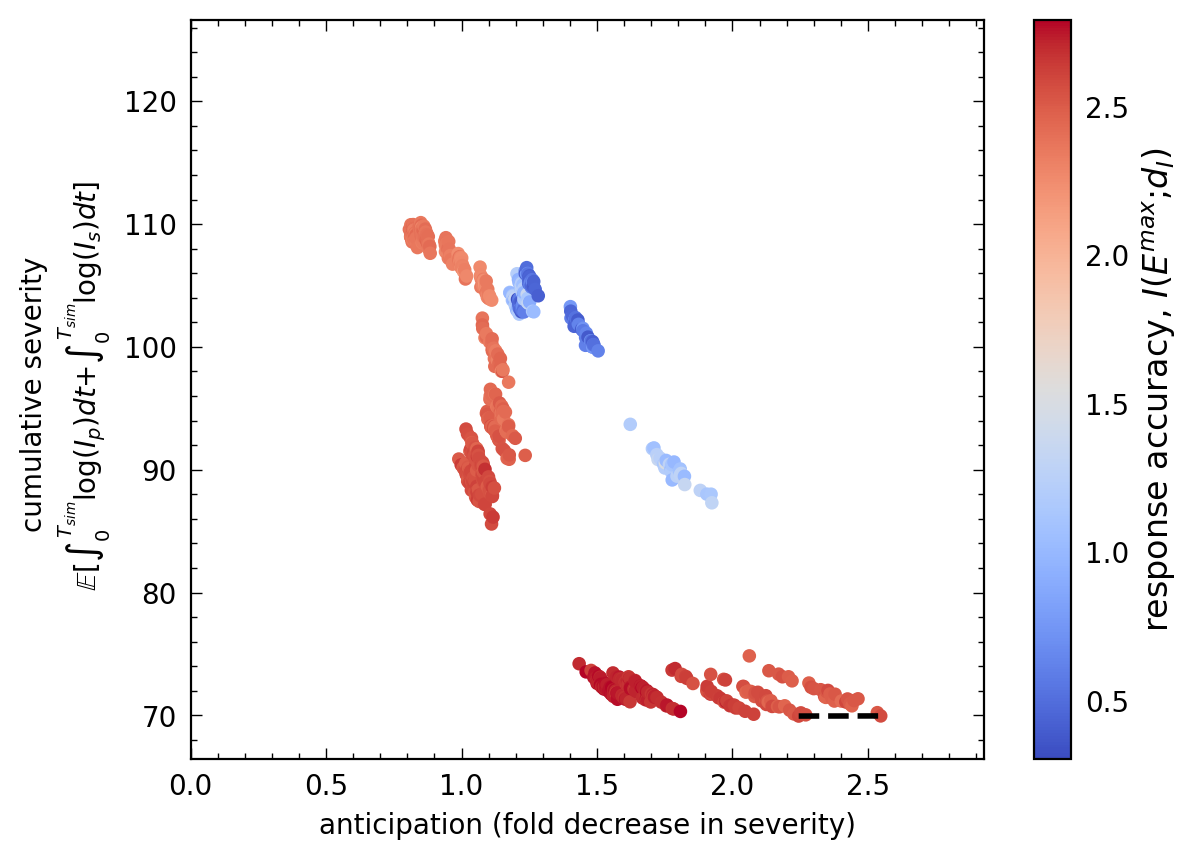

In [37]:
x = (full_net_data['s_p_harm'].to_numpy())/(full_net_data['s_s_harm'].to_numpy())
y = (full_net_data['s_p_harm'].to_numpy())+(full_net_data['s_s_harm'].to_numpy())
z = full_net_data['p_mi_d_I_max_E'].to_numpy()
xyz = (np.array([x , y, z]).T)[x.argsort()]

plt.scatter(xyz[:,0], xyz[:,1],
           c = xyz[:,2], cmap='coolwarm', s = 15)

plt.colorbar(label =r"response accuracy, "+r"$I($"+stat_names[13]+r";$d_I)$")

# find pareto front
remove_row = np.ones(xyz.shape[0], dtype = bool)

for j in np.arange(len(xyz[:,0])):
    for k in np.arange(len(xyz[:,0])):
        if xyz[j,0] < xyz[k,0] and xyz[j,1] > xyz[k,1]:
            remove_row[j] = False


x_front = (xyz[:,0])[remove_row,...]
y_front = (xyz[:,1])[remove_row,...]
#ax.scatter(x_front, y_front, c='#252525')
plt.plot(x_front, y_front, 'k--', linewidth=2)

plt.axis([0.0, np.max(xyz[:,0])*1.15, 0.95*np.min(xyz[:,1]), np.max(xyz[:,1])*1.15])
plt.xlabel(r"anticipation (fold decrease in severity)", fontsize = 10)
plt.ylabel("cumulative severity \n $\mathbb{E}[$"+stat_names[-9]+r"+"+stat_names[-7]+r"$]$", fontsize = 10)

plt.savefig('_figs/pareto_fld_chg_v_cumu_harm_w_p_sens_bI'+'.png', dpi=300, bbox_inches="tight")

In [38]:
low, high = 10, 160
eff_nets = full_net_data.loc[full_net_data.p_int_E >= low]
eff_nets['cumu_harm'] = -(eff_nets['p_p_harm']+eff_nets['s_s_harm'])
eff_nets['fld_chg'] = -(eff_nets['p_p_harm']/eff_nets['s_s_harm'])
eff_nets.sort_values(by=['cumu_harm', 'fld_chg'], ascending=False, inplace=True)

print((eff_nets.to_numpy())[0:50,0:6])

[[2. 0. 2. 0. 2. 2.]
 [2. 0. 0. 0. 1. 2.]
 [1. 1. 2. 0. 0. 1.]
 [2. 0. 2. 0. 0. 2.]
 [0. 1. 1. 0. 2. 1.]
 [2. 0. 2. 0. 0. 1.]
 [0. 1. 0. 0. 2. 2.]
 [0. 2. 2. 0. 0. 2.]
 [1. 1. 2. 0. 2. 2.]
 [1. 1. 1. 0. 2. 2.]
 [2. 0. 0. 0. 2. 2.]
 [0. 2. 2. 0. 1. 2.]
 [2. 0. 2. 0. 1. 1.]
 [0. 2. 0. 0. 2. 2.]
 [1. 1. 2. 0. 2. 1.]
 [1. 1. 2. 0. 0. 2.]
 [2. 0. 2. 0. 1. 2.]
 [1. 1. 1. 0. 1. 2.]
 [2. 0. 2. 0. 2. 0.]
 [0. 2. 1. 0. 0. 2.]
 [2. 0. 1. 0. 0. 2.]
 [1. 1. 0. 0. 2. 2.]
 [0. 2. 2. 0. 0. 1.]
 [0. 2. 2. 0. 2. 1.]
 [1. 1. 2. 0. 1. 2.]
 [1. 1. 1. 0. 2. 1.]
 [2. 1. 2. 0. 2. 1.]
 [2. 0. 0. 0. 0. 2.]
 [2. 0. 1. 0. 2. 1.]
 [0. 2. 1. 0. 2. 1.]
 [1. 2. 2. 0. 1. 2.]
 [0. 1. 0. 0. 1. 2.]
 [2. 0. 1. 0. 1. 2.]
 [2. 1. 2. 0. 1. 1.]
 [2. 1. 0. 0. 1. 2.]
 [2. 1. 2. 0. 2. 2.]
 [1. 1. 2. 0. 1. 1.]
 [2. 1. 1. 0. 1. 2.]
 [1. 1. 0. 0. 2. 1.]
 [2. 0. 1. 0. 1. 1.]
 [1. 2. 1. 0. 0. 2.]
 [1. 1. 0. 0. 1. 1.]
 [2. 0. 0. 0. 0. 1.]
 [0. 1. 2. 0. 0. 2.]
 [2. 0. 2. 0. 2. 1.]
 [2. 1. 2. 0. 1. 2.]
 [1. 2. 2. 0. 1. 1.]
 [2. 2. 2. 0.

/tmp/ipykernel_12588/1162654912.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eff_nets['cumu_harm'] = -(eff_nets['p_p_harm']+eff_nets['s_s_harm'])
/tmp/ipykernel_12588/1162654912.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eff_nets['fld_chg'] = -(eff_nets['p_p_harm']/eff_nets['s_s_harm'])
/tmp/ipykernel_12588/1162654912.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

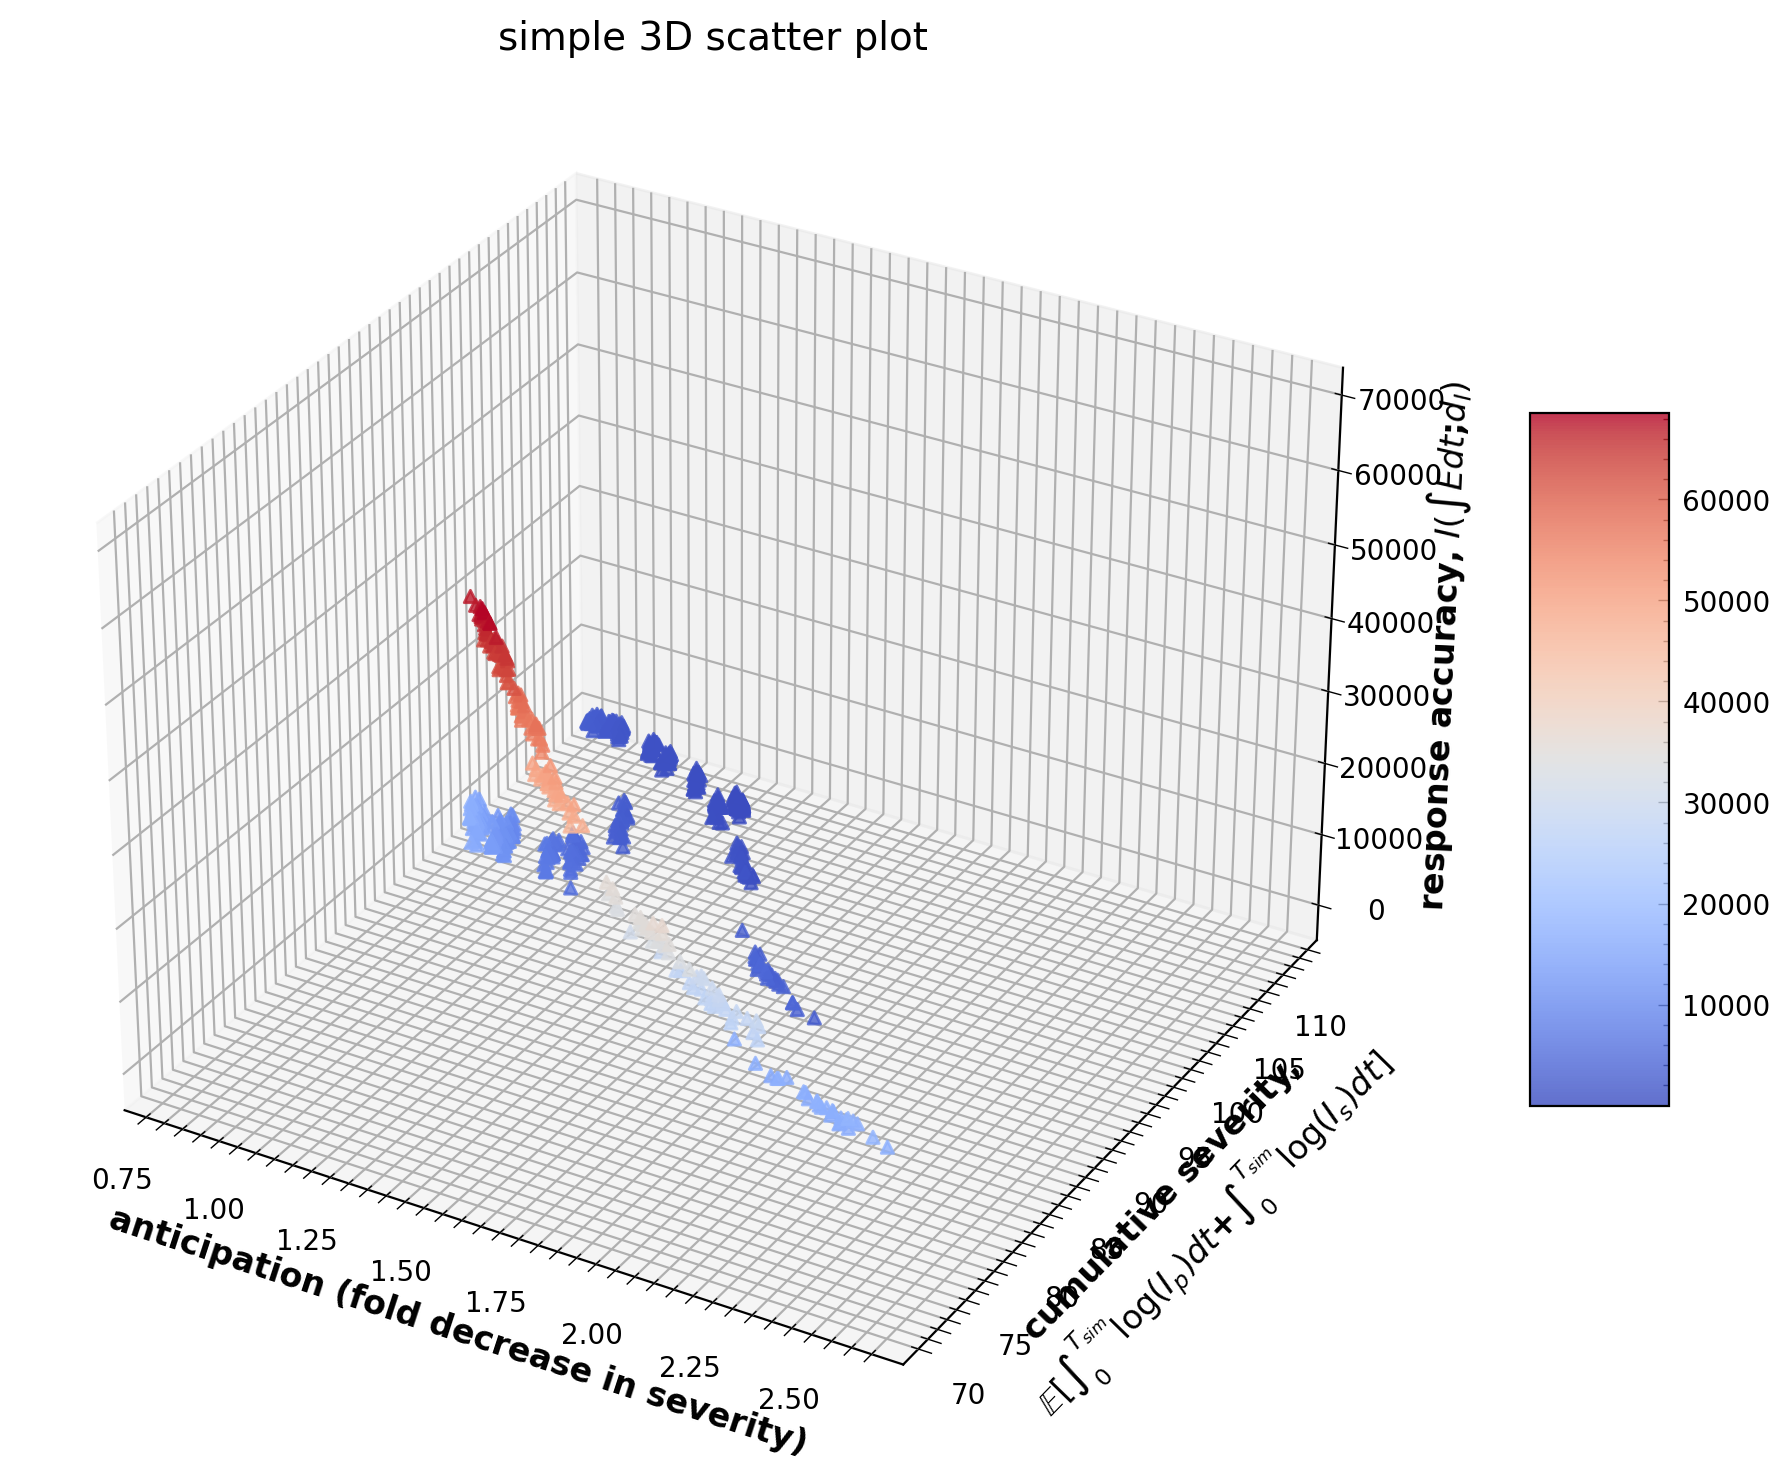

In [39]:
fig = plt.figure(figsize = (16, 9))
ax = plt.axes(projection ="3d")

x = (full_net_data['p_p_harm'].to_numpy())/(full_net_data['s_s_harm'].to_numpy())
y = (full_net_data['p_p_harm'].to_numpy())+(full_net_data['s_s_harm'].to_numpy())
z = full_net_data['p_mi_d_I_int_E']
heat = z = full_net_data['p_int_E']

# Add x, y gridlines
ax.grid(visible = True, color ='grey',
        linestyle ='-.', linewidth = 0.3,
        alpha = 0.2)
 
 
# Creating color map
my_cmap = plt.get_cmap('hsv')
 
# Creating plot
sctt = ax.scatter3D(x, y, z,
                    alpha = 0.8,
                    c = heat,
                    cmap = "coolwarm",
                    marker ='^')
 
plt.title("simple 3D scatter plot")
ax.set_xlabel(r"anticipation (fold decrease in severity)", fontweight ='bold')
ax.set_ylabel("cumulative severity, \n $\mathbb{E}[$"+stat_names[-9]+r"+"+stat_names[-7]+r"$]$", fontweight ='bold')
ax.set_zlabel(r"response accuracy, "+r"$I($"+stat_names[16]+r";$d_I)$", fontweight ='bold')
fig.colorbar(sctt, ax = ax, shrink = 0.5, aspect = 5)
 
# show plot
plt.show()

In [40]:
# # plot pareto front for appropriateness and effectiveness of the immune response
# fig_d_I = plt.figure(figsize=(12,12),dpi = 600)

# i = 0

# for val in stat_names_df[i+10:]:
    
#     # select variables for antigenicity
#     xy = (np.array([net_data[:,i+6] ,net_data[:,-7]]).T)[(net_data[:,i+6]).argsort()]
    
#     # hull = ConvexHull(np.array([x_, y_]).T)
    
#     ax = fig_d_I.add_subplot(5, 2, i+1)
#     cs = ax.scatter(xy[:,0], xy[:,1], c='#969696')
    
#     # find pareto front
#     remove_row = np.ones(xy.shape[0], dtype = bool)
    
#     for j in np.arange(len(xy[:,0])):
#         for k in np.arange(len(xy[:,0])):
#             if xy[j,0] < xy[k,0] and xy[j,1] > xy[k,1]:
#                 remove_row[j] = False
                
    
#     x_front = (xy[:,0])[remove_row,...]
#     y_front = (xy[:,1])[remove_row,...]
#     #ax.scatter(x_front, y_front, c='#252525')
#     ax.plot(x_front, y_front, c='#252525', linewidth=3)
    
#     ax.axis([0.0, np.max(xy[:,0])*1.15, 0.95*np.min(xy[:,1]), np.max(xy[:,1])*1.15])
#     # for k in np.arange(0,len(x_front)):
#     #     ax.text(x_front[k],y_front[k], k, ha="center", va="center")
    
#     # inset plot: these are in unitless percentages of the figure size. (0,0 is bottom left)
#     axins = inset_axes(ax, width="25%", height="25%", loc=2, borderpad = 3.2)
#     axins.scatter(net_data[remove_row,4], net_data[remove_row,5], c ='#252525')
#     axins.scatter(net_data[np.argmin(xy[:,1]),4], net_data[np.argmin(xy[:,1]),5], c ='#e34a33')
#     axins.scatter(net_data[np.argmax(xy[:,0]),4], net_data[np.argmax(xy[:,0]),5], c = '#6baed6')
#     axins.set(xlabel=r'$\psi_{E,E}^{(I)}$', ylabel=r'$\psi_{E,E}^{(c)}$')
#     axins.axis([-0.05, 1.05, -0.05, 1.05])

#     # set the limits of the plot to the limits of the data
#     ax.set(xlabel=r"$I($"+val+r";$N_0)$", ylabel=r"$\mathbb{E}_{\sim N_0, d_I}[$"+stat_names[10]+r"$]$")
#     #ax.set(xlabel="accuracy with antigenicity (bits)", ylabel="harm")
    
#     i += 1
    
# #fig_d_I.suptitle(r'Pareto front over $(\psi_{N,E}^{(I)},\psi_{N,E}^{(c)},\psi_{cM,E}^{(I)},\psi_{cM,E}^{(c)}, \psi_{E,E}^{(I)}, \psi_{E,E}^{(c)})$'+' for '+infection_type+". infection")
# #fig_d_I.savefig("_figs/"+sim_kind+'-'+infection_type+'-pareto-over-all-antigenicity.png', dpi=600)#, bbox_inches="tight")
# plt.tight_layout()

# plt.show()

In [41]:
# # plot pareto front for appropriateness and effectiveness of the immune response
# fig_d_I = plt.figure(figsize=(12,12),dpi = 600)

# i = 0

# for val in stat_names[i+10:]:

#     xy = (np.array([net_data[:,i+6] ,net_data[:,-6]]).T)[(net_data[:,i+6]).argsort()]
    
#     # hull = ConvexHull(np.array([x_, y_]).T)
    
#     ax = fig_d_I.add_subplot(5, 2, i+1)
#     cs = ax.scatter(xy[:,0], xy[:,1], c='#969696')
    
#     # find pareto front
#     remove_row = np.ones(xy.shape[0], dtype = bool)
    
#     for j in np.arange(len(xy[:,0])):
#         for k in np.arange(len(xy[:,0])):
#             if xy[j,0] < xy[k,0] and xy[j,1] < xy[k,1]:
#                 remove_row[j] = False
                
    
#     x_front = (xy[:,0])[remove_row,...]
#     y_front = (xy[:,1])[remove_row,...]
#     ax.plot(x_front, y_front, c='#252525', linewidth = 3.0)
    
#     ax.axis([0.0, np.max(xy[:,0])*1.15, 0.95*np.min(xy[:,1]), np.max(xy[:,1])*0.000000015])
#     # for k in np.arange(0,len(x_front)):
#     #     ax.text(x_front[k],y_front[k], k, ha="center", va="center")
    
#     # inset plot: these are in unitless percentages of the figure size. (0,0 is bottom left)
#     axins = inset_axes(ax, width="25%", height="25%", loc=2, borderpad = 3.2)
#     axins.scatter(net_data[remove_row,4], net_data[remove_row,5], c ='#252525')
#     axins.scatter(net_data[np.argmin(xy[:,1]),4], net_data[np.argmin(xy[:,1]),5], c ='#e34a33')
#     axins.scatter(net_data[np.argmax(xy[:,0]),4], net_data[np.argmax(xy[:,0]),5], c = '#6baed6')
#     axins.set(xlabel=r'$\psi_{E,E}^{(I)}$', ylabel=r'$\psi_{E,E}^{(c)}$')
#     axins.axis([-0.05, 1.05, -0.05, 1.05])

#     # set the limits of the plot to the limits of the data
#     ax.set(xlabel=r"$I($"+val+r";$N_0)$", ylabel=r"$\mathbb{E}_{\sim N_0, d_I}[$"+stat_names[-6]+r"$]$")
#     #ax.set(xlabel="accuracy with antigenicity (bits)", ylabel="harm")
    
#     i += 1
    
# #fig_d_I.suptitle(r'Pareto front over $(\psi_{N,E}^{(I)},\psi_{N,E}^{(c)},\psi_{cM,E}^{(I)},\psi_{cM,E}^{(c)}, \psi_{E,E}^{(I)}, \psi_{E,E}^{(c)})$'+' for '+infection_type+". infection")
# #fig_d_I.savefig("_figs/"+sim_kind+'-'+infection_type+'-pareto-over-all-antigenicity.png', dpi=600)#, bbox_inches="tight")
# plt.tight_layout()

# plt.show()

In [42]:
# # plot pareto front for different measures of effectiveness of the immune response
# fig_d_I = plt.figure(figsize=(12,12),dpi = 150)

# i = 0

# for val in stat_names[i+10:]:

#     xy = (np.array([net_data[:,i+24],net_data[:,-7]]).T)[(net_data[:,i+24]).argsort()]
    
#     # hull = ConvexHull(np.array([x_, y_]).T)
    
#     ax = fig_d_I.add_subplot(5, 2, i+1)
#     cs = ax.scatter(xy[:,0], xy[:,1], c='#969696')
    
#     # find pareto front
#     remove_row = np.ones(xy.shape[0], dtype = bool)
    
#     for j in np.arange(len(xy[:,0])):
#         for k in np.arange(len(xy[:,0])):
#             if xy[j,0] > xy[k,0] and xy[j,1] > xy[k,1]:
#                 remove_row[j] = False
                
    
#     x_front = (xy[:,0])[remove_row,...]
#     y_front = (xy[:,1])[remove_row,...]
#     ax.plot(x_front, y_front, c='#252525', linewidth = 3)
    
#     ax.axis([0.0, np.max(xy[:,0])*1.15, 0.95*np.min(xy[:,1]), np.max(xy[:,1])*1.15])
#     # for k in np.arange(0,len(x_front)):
#     #     ax.text(x_front[k],y_front[k], k, ha="center", va="center")
    
#     # inset plot: these are in unitless percentages of the figure size. (0,0 is bottom left)
#     axins = inset_axes(ax, width="25%", height="25%", loc=2, borderpad = 3.2)
#     axins.scatter(net_data[remove_row,4], net_data[remove_row,5], c ='#252525')
#     axins.scatter(net_data[np.argmin(xy[:,1]),4], net_data[np.argmin(xy[:,1]),5], c ='#e34a33') #effectiveness
#     axins.scatter(net_data[np.argmax(xy[:,0]),4], net_data[np.argmax(xy[:,0]),5], c = '#6baed6') # responsiveness
#     axins.set(xlabel=r'$\psi_{E,E}^{(I)}$', ylabel=r'$\psi_{E,E}^{(c)}$')
#     axins.axis([-0.05, 1.05, -0.05, 1.05])

#     # set the limits of the plot to the limits of the data
#     ax.set(xlabel=r"$\mathbb{E}_{\sim N_0, d_I}[$"+val+r"$]$", ylabel=r"$\mathbb{E}_{\sim N_0, d_I}[$"+stat_names[10]+r"$]$")
#     #ax.set(xlabel="accuracy with virulence (bits)", ylabel="harm")
    
#     i += 1
    
# #fig_d_I.suptitle(r'Pareto front over $(\psi_{N,E}^{(I)},\psi_{N,E}^{(c)},\psi_{cM,E}^{(I)},\psi_{cM,E}^{(c)}, \psi_{E,E}^{(I)}, \psi_{E,E}^{(c)})$'+' for '+infection_type+". infection")
# #fig_d_I.savefig("_figs/"+sim_kind+'-'+infection_type+'-pareto-over-all-virulence.png', dpi=600)#, bbox_inches="tight")
# plt.tight_layout()

# plt.show()